In [616]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [617]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [618]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [619]:
protons = protons[(protons['height'] < 100) & (protons['width'] < 400)]

In [620]:
deuterons = deuterons[(deuterons['height'] < 100) & (deuterons['width'] < 400)]

In [621]:
protons.shape, deuterons.shape

((6291, 37), (5115, 37))

In [622]:
protons

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,normalised,adcdiff,maxdiff,energy,rr,e_diff,rr_diff,p,m,beamline_mass
1,1,8557,9,700,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1958.0,...,"[0.12811387900355872, 0.2775800711743772, 0.36...","[0.1494661921708185, 0.0889679715302491, 0.032...",0.149466,"[767.0, 1666.0, 2127.0, 2349.0, 2548.0, 2229.0...","[58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 4...","[899.0, 461.0, 222.0, 199.0, -319.0, -56.0, -1...","[57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 4...",1,1,957.13
2,2,8557,10,734,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1086.0,...,"[0.312280701754386, 0.4982456140350877, 0.4842...","[0.18596491228070172, -0.014035087719298234, 0...",0.185965,"[2285.0, 3088.0, 2916.0, 3451.0, 3571.0, 2901....","[29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 1...","[803.0, -172.0, 535.0, 120.0, -670.0, -466.0, ...","[28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 1...",1,1,843.70
3,3,8557,16,995,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,995.0,...,"[0.06569343065693431, 0.29927007299270075, 0.5...","[0.23357664233576644, 0.2664233576642336, 0.0,...",0.266423,"[169.0, 2241.0, 3502.0, 3343.0, 3430.0, 3434.0...","[24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 1...","[2072.0, 1261.0, -159.0, 87.0, 4.0, -467.0, -2...","[23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 1...",1,1,958.97
4,4,8557,16,1015,/Users/user/data/research/proton-deuteron/rawp...,1,proton,induction,0,2231.0,...,"[0.08542713567839195, 0.33668341708542715, 0.4...","[0.2512562814070352, 0.10552763819095479, -0.0...",0.251256,"[165.0, 1443.0, 1799.0, 1703.0, 1780.0, 1882.0...","[69, 68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 5...","[1278.0, 356.0, -96.0, 77.0, 102.0, 239.0, -13...","[68, 67, 66, 65, 64, 63, 62, 61, 60, 59, 58, 5...",1,1,1286.61
6,6,8557,19,1169,/Users/user/data/research/proton-deuteron/rawp...,1,proton,induction,0,1954.0,...,"[0.08881578947368421, 0.35526315789473684, 0.3...","[0.26644736842105265, 0.023026315789473673, -0...",0.266447,"[647.0, 2417.0, 2333.0, 2230.0, 1909.0, 2142.0...","[59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 4...","[1770.0, -84.0, -103.0, -321.0, 233.0, -28.0, ...","[58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 4...",1,1,916.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7443,7631,9788,297,26027,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1550.0,...,"[0.16463414634146342, 0.36585365853658536, 0.4...","[0.20121951219512194, 0.06707317073170732, 0.0...",0.201220,"[500.0, 1302.0, 1419.0, 1462.0, 1557.0, 1435.0...","[49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 3...","[802.0, 117.0, 43.0, 95.0, -122.0, 145.0, -203...","[48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 3...",1,1,1006.39
7444,7632,9788,299,26208,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1456.0,...,"[0.16, 0.4, 0.3933333333333333, 0.386666666666...","[0.24000000000000002, -0.00666666666666671, -0...",0.240000,"[448.0, 1165.0, 1092.0, 1095.0, 1356.0, 1012.0...","[50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 3...","[717.0, -73.0, 3.0, 261.0, -344.0, -46.0, 41.0...","[49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 3...",1,1,929.77
7445,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,534.0,...,"[0.2714285714285714, 0.8571428571428571, 1.0, ...","[0.5857142857142856, 0.1428571428571429, -0.27...",0.585714,"[340.0, 1395.0, 1448.0, 1026.0, 973.0, 1039.0,...","[18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, ...","[1055.0, 53.0, -422.0, -53.0, 66.0, -22.0, -12...","[17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5...",1,1,883.31
7446,7634,9788,308,26943,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1359.0,...,"[0.10625, 0.3125, 0.41875, 0.48125, 0.425, 0.4...","[0.20625, 0.10625000000000001, 0.0625, -0.0562...",0.206250,"[166.0, 1035.0, 1341.0, 1592.0, 1315.0, 1300.0...","[45, 44, 4

In [623]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(399, 99, 399, 99)

In [624]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

<Axes: >

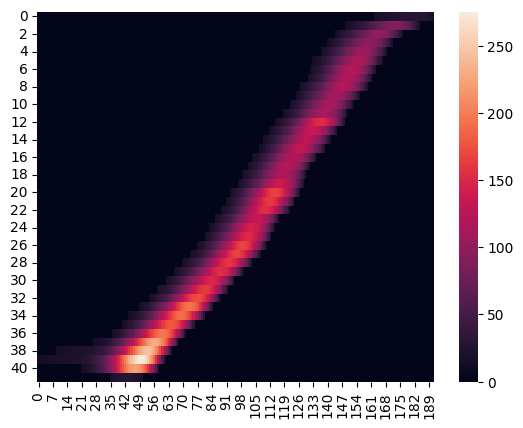

In [625]:
i = 14
sns.heatmap(protons['image_intensity'].iloc[i])

In [626]:
int(np.argmax(protons['image_intensity'].iloc[i][0]))

180

In [627]:
pv = []                                                 # vertex
pe = []                                                 # end   
for idx, row in protons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    pv.append(vertex)
    pe.append(end)

pv = np.array(pv)
pe = np.array(pe)

dv = []                                                 # vertex
de = []                                                 # end   
for idx, row in deuterons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    dv.append(vertex)
    de.append(end)

np.int64(-348)

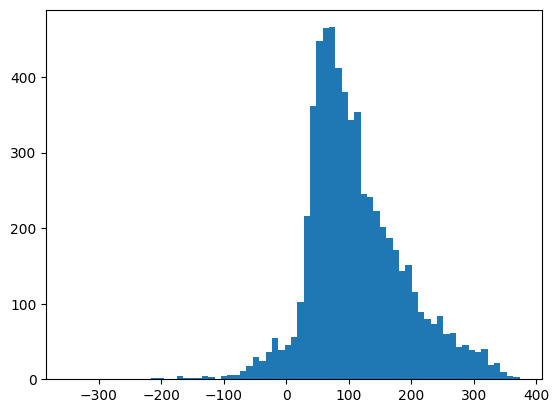

In [628]:
plt.hist(pv - pe, bins='auto')
min(pv-pe)

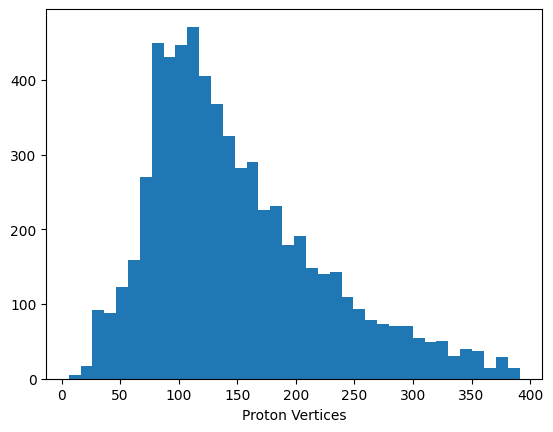

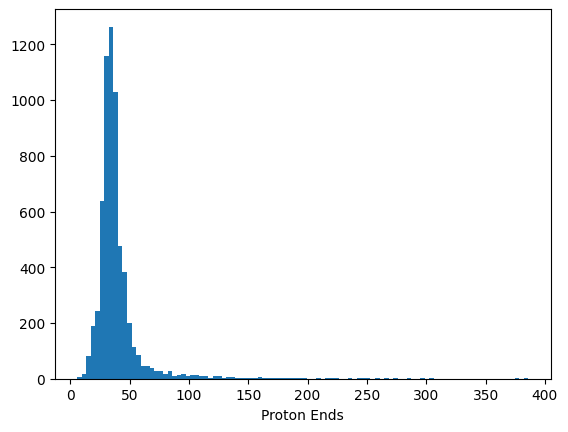

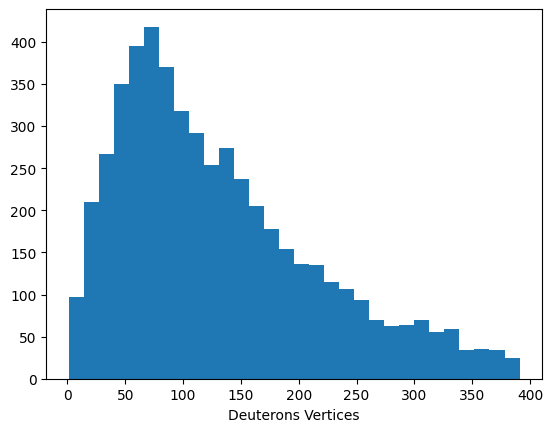

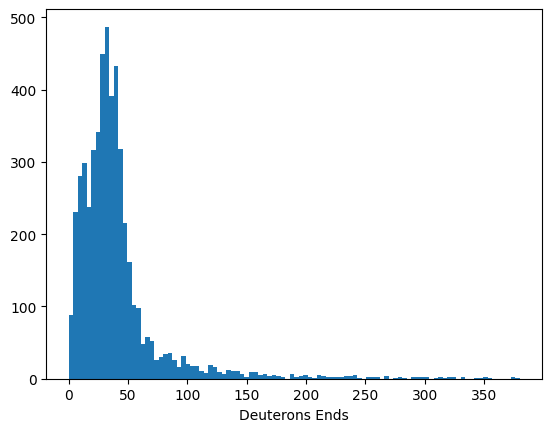

In [629]:
plt.hist(pv, bins='auto'); plt.xlabel('Proton Vertices'); plt.show()
plt.hist(pe, bins=100); plt.xlabel('Proton Ends'); plt.show()
plt.hist(dv, bins='auto'); plt.xlabel('Deuterons Vertices'); plt.show()
plt.hist(de, bins=100); plt.xlabel('Deuterons Ends'); plt.show()

<Axes: >

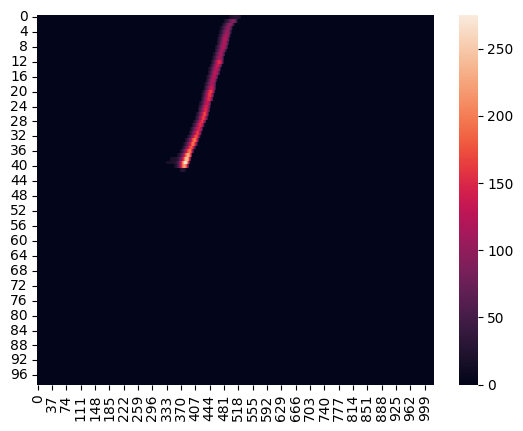

In [630]:
pad = pad_image(protons['image_intensity'].iloc[i])
sns.heatmap(pad)

In [631]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [632]:
p = [] 
d = []

for idx, row in protons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    p.append(padded)

for idx, row in deuterons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    d.append(padded)

p = np.array(p)
d = np.array(d)

p_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p])
d_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d])

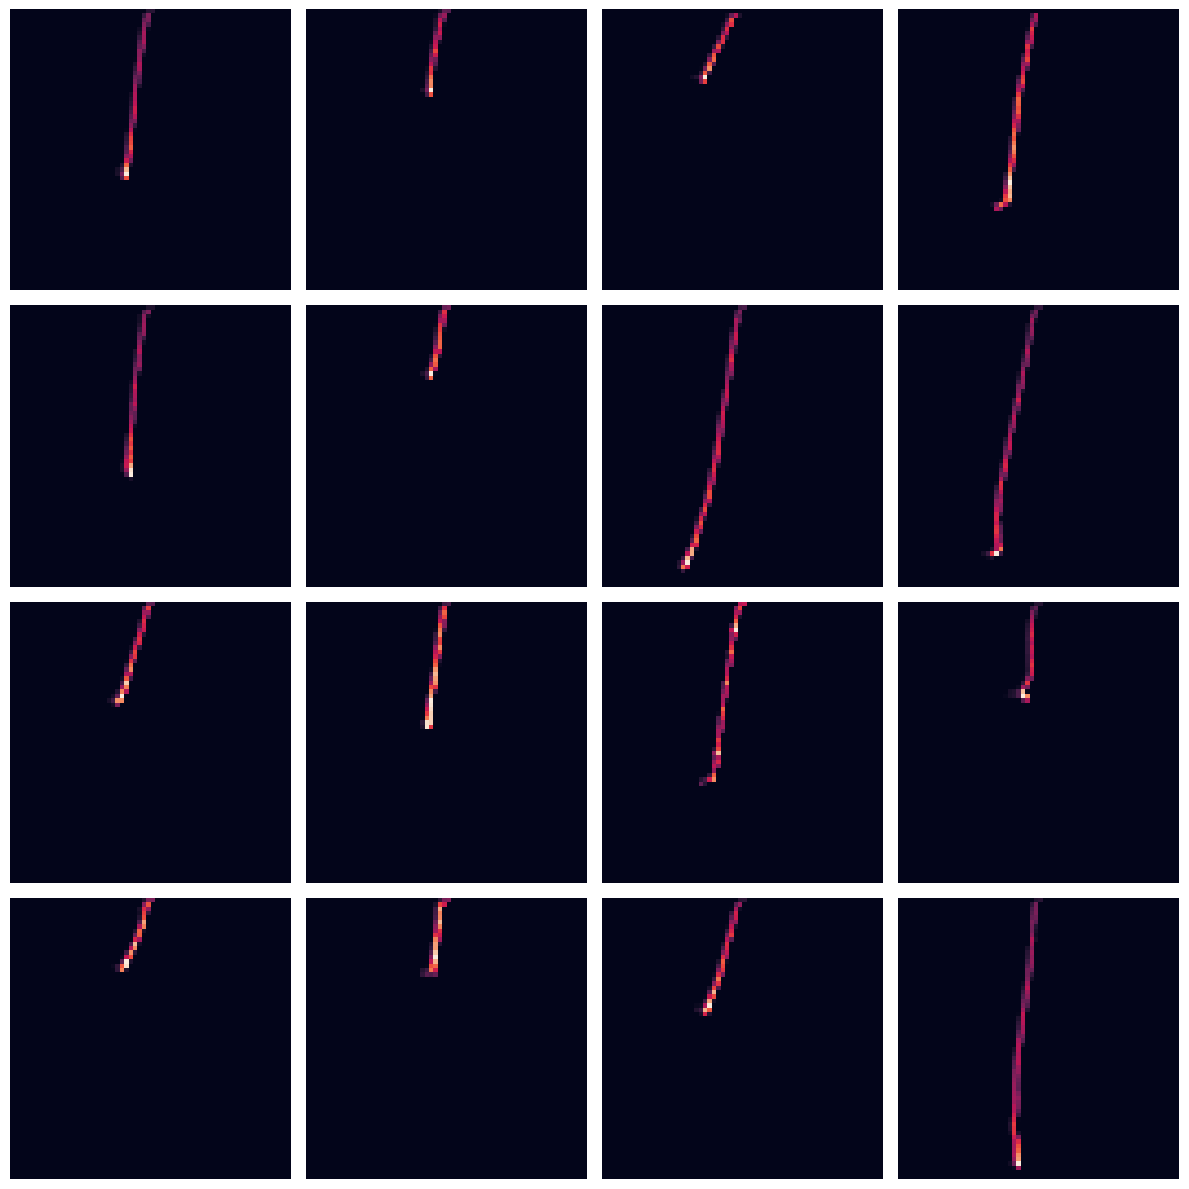

In [633]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

selected_images = p_d[:num_images]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i], ax=ax, cbar=False, square=True, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

plt.tight_layout()
plt.show()

In [634]:
imgpv = []                                                 # vertex
imgpe = []                                                 # end   
for img in p_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgpv.append(vertex)
    imgpe.append(end)

imgdv = []                                                 # vertex
imgde = []                                                 # end   
for img in d_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgdv.append(vertex)
    imgde.append(end)

32


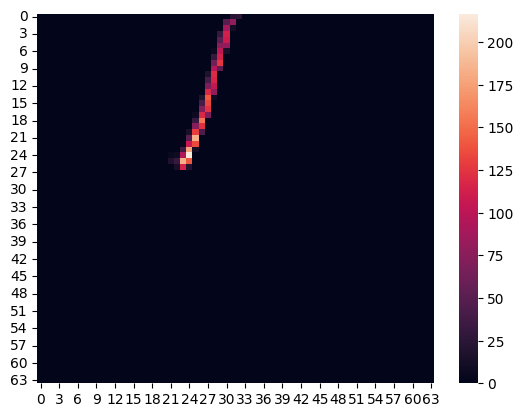

In [635]:
sns.heatmap(p_d[14]); print(np.argmax(p_d[i][0]))

<Axes: >

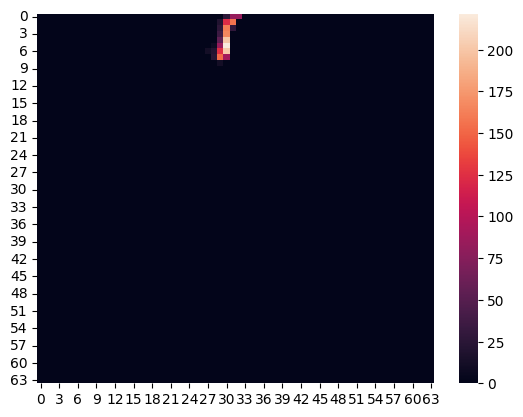

In [636]:
sns.heatmap(d_d[0])

In [637]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [638]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p_d, dtype=torch.float32)  # shape (N, H, W)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 50
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_d_d = []

Training device: mps



===== Fold 1/5 =====
Epoch 1/50: Train=56.9641837229, Val=31.4272771358
Epoch 2/50: Train=26.0159058511, Val=23.1536306143
Epoch 3/50: Train=19.6986154846, Val=18.8299738407
Epoch 4/50: Train=15.3634144807, Val=15.3949530721
Epoch 5/50: Train=13.4505671489, Val=13.6858406067
Epoch 6/50: Train=11.7265351120, Val=12.2568264723
Epoch 7/50: Train=10.9878407370, Val=11.2084275126
Epoch 8/50: Train=9.9395962848, Val=12.4817452908
Epoch 9/50: Train=9.5083886038, Val=9.9571001768
Epoch 10/50: Train=8.5666946369, Val=9.0742558002
Epoch 11/50: Train=8.4409334961, Val=9.5415722251
Epoch 12/50: Train=8.2576770601, Val=8.7117645323
Epoch 13/50: Train=7.4776219326, Val=8.8114645481
Epoch 14/50: Train=7.0948567451, Val=8.1020687401
Epoch 15/50: Train=6.8113685167, Val=8.3805863142
Epoch 16/50: Train=6.7553972896, Val=8.4396042705
Epoch 17/50: Train=6.5358093177, Val=7.7702257812
Epoch 18/50: Train=6.2852563375, Val=8.0262663603
Epoch 19/50: Train=6.0681016189, Val=7.7425793648
Epoch 20/50: Train=5.7

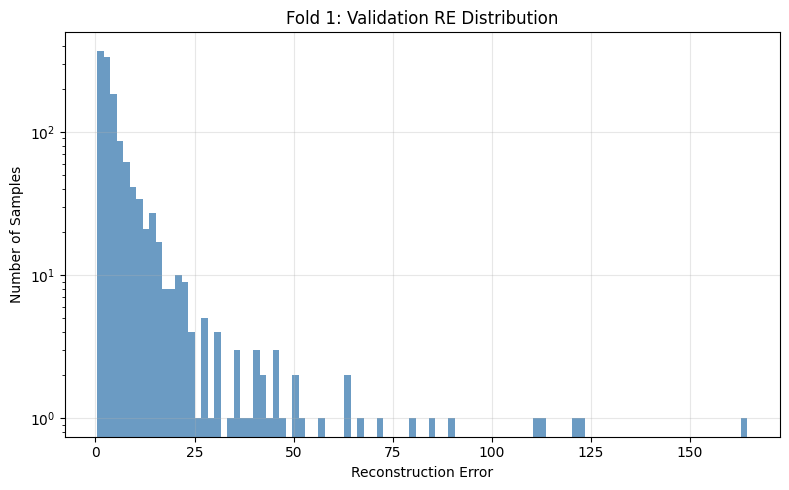

Computing RE on unseen dataset (d_d)...


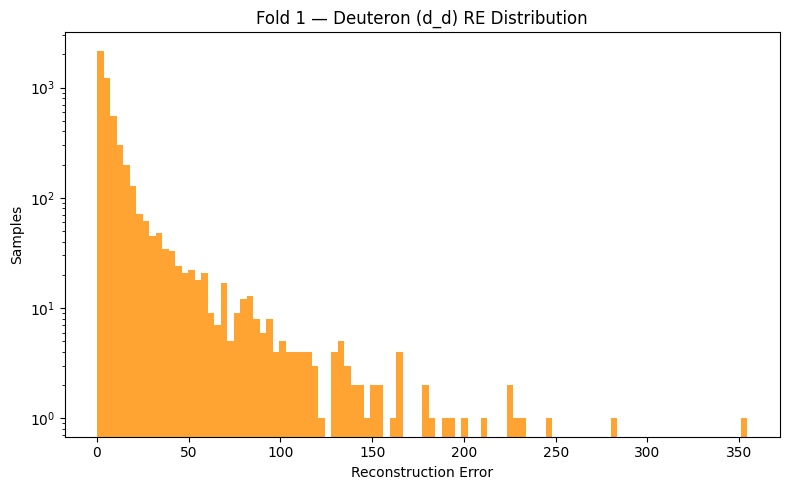


===== Fold 2/5 =====
Epoch 1/50: Train=60.2930743906, Val=34.4759111643
Epoch 2/50: Train=27.6323724698, Val=21.8639598608
Epoch 3/50: Train=20.5231714732, Val=17.9510194063
Epoch 4/50: Train=16.8464225516, Val=14.8459581971
Epoch 5/50: Train=14.1057563613, Val=12.5935137391
Epoch 6/50: Train=13.0554698510, Val=12.1114306688
Epoch 7/50: Train=11.3669853814, Val=11.8918150067
Epoch 8/50: Train=10.7020775548, Val=10.0405894279
Epoch 9/50: Train=9.8376984747, Val=9.5704897761
Epoch 10/50: Train=9.2656337521, Val=10.2902536750
Epoch 11/50: Train=8.4424356539, Val=9.1297529042
Epoch 12/50: Train=8.2938597112, Val=9.8157712698
Epoch 13/50: Train=7.9799406196, Val=8.1960348666
Epoch 14/50: Train=7.3836088482, Val=8.3622554064
Epoch 15/50: Train=7.1133087225, Val=7.6970144510
Epoch 16/50: Train=6.5871172344, Val=7.7546727717
Epoch 17/50: Train=6.5849093546, Val=7.3657409608
Epoch 18/50: Train=6.0695517184, Val=7.1097101212
Epoch 19/50: Train=6.2980163309, Val=7.5272215307
Epoch 20/50: Train=6

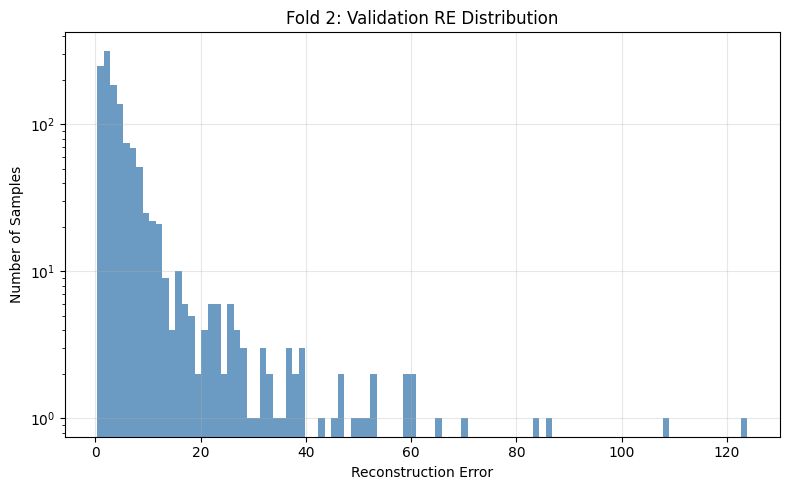

Computing RE on unseen dataset (d_d)...


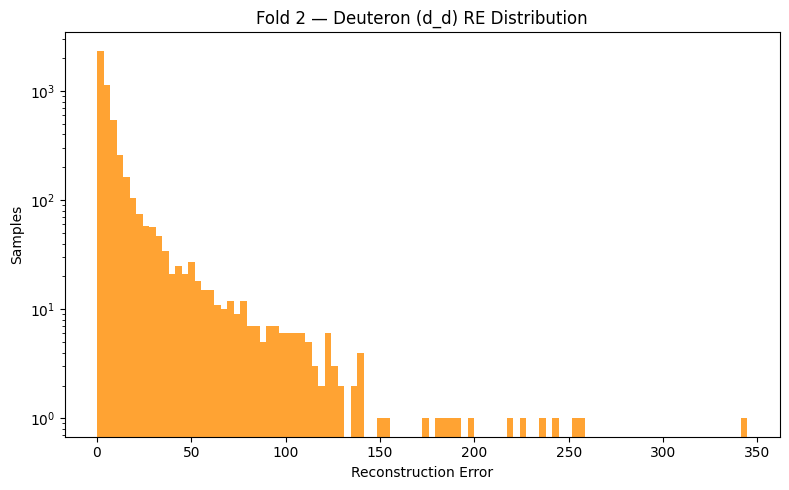


===== Fold 3/5 =====
Epoch 1/50: Train=58.5850084764, Val=35.5613733768
Epoch 2/50: Train=28.2388040929, Val=22.8404252887
Epoch 3/50: Train=20.8393589454, Val=18.9944911003
Epoch 4/50: Train=16.6769956939, Val=15.1688189685
Epoch 5/50: Train=14.4875686320, Val=15.0105890751
Epoch 6/50: Train=12.7094369055, Val=12.8991409481
Epoch 7/50: Train=11.7691536191, Val=11.9168785155
Epoch 8/50: Train=11.2166567815, Val=10.9058569551
Epoch 9/50: Train=10.2175557432, Val=10.3711312890
Epoch 10/50: Train=9.6081024755, Val=9.9164980292
Epoch 11/50: Train=8.8212638143, Val=10.4669685543


In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=16).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.10f}, Val={val_losses[-1]:.10f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, H, W = X_val_np.shape
    recon_all = np.empty((N, H, W), dtype=np.float32)

    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (d_d) ======
    # ============================================================

    print("Computing RE on unseen dataset (d_d)...")

    Xd_np = d_d.astype(np.float32)       # unseen data
    N, H, W = Xd_np.shape
    recon_all_d = np.empty((N, H, W), dtype=np.float32)
    latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_d[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_d[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_d_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2))
    fold_REs_d_d.append(RE_d_d)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_d_d, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d_d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

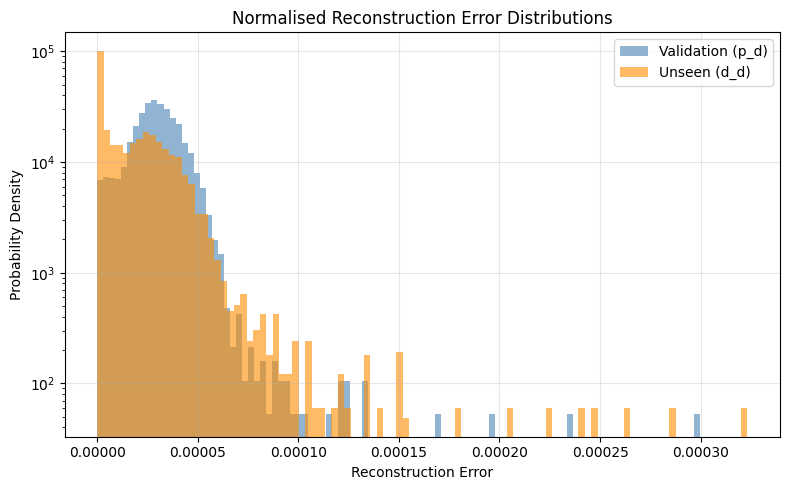

Validation mean RE: 0.0000299407 ± 0.0000139864
Unseen (d_d) mean RE: 0.0000184773 ± 0.0000206283


In [ ]:
all_RE_val = np.concatenate(fold_REs)
all_RE_d_d  = np.concatenate(fold_REs_d_d)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_d_d, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (d_d)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.10f} ± {all_RE_val.std():.10f}")
print(f"Unseen (d_d) mean RE: {all_RE_d_d.mean():.10f} ± {all_RE_d_d.std():.10f}")

Inference device: mps
recon_all.shape: (5033, 64, 64)
latent_vectors.shape: (5033, 16)
RE_per_sample.shape: (5033,)


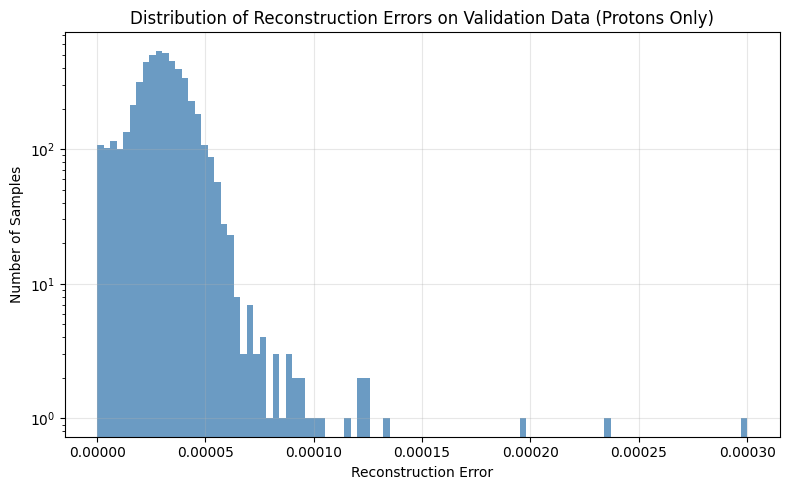

In [ ]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (1258, 64, 64)
latent_vectors.shape: (1258, 16)
RE_per_sample.shape: (1258,)


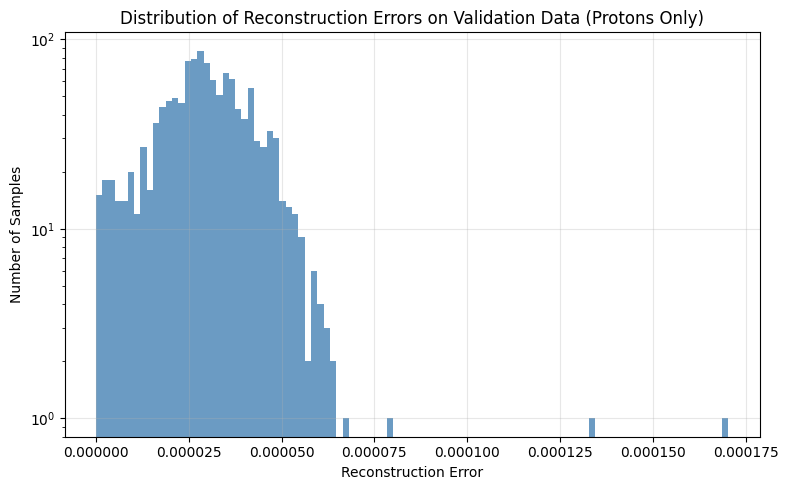

In [ ]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_nval = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_nval.shape

batch_size = 8   
recon_all_val = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_nval[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all_val[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all_val - X_nval) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all_val.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all_d.shape: (5115, 64, 64)
latent_vectors.shape: (5115, 16)
RE_per_sample_d.shape: (5115,)


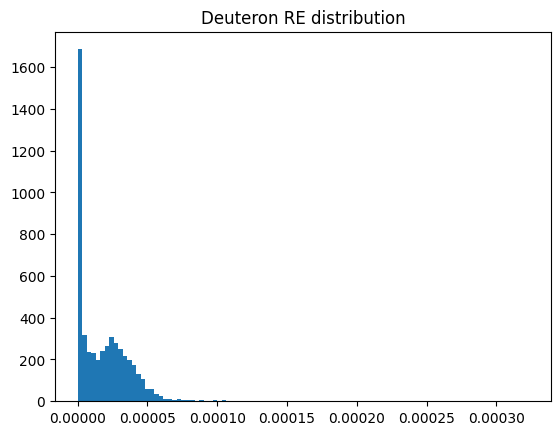

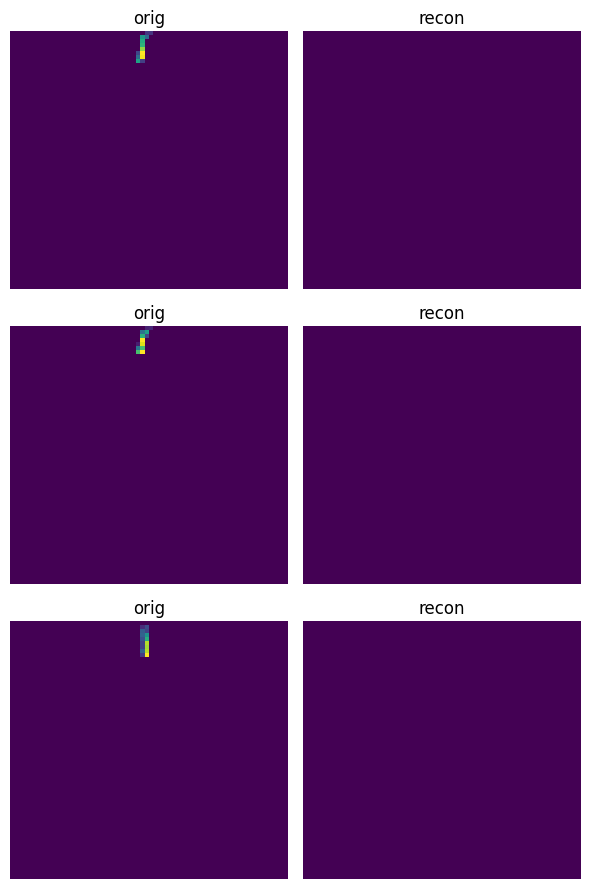

In [ ]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d_d.astype(np.float32)          # (N, H, W)
N, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all_d = np.empty((N, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all_d[i:j] = out.cpu().numpy()

        enc = model.encoder(xb.unsqueeze(1))    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_d[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2))

print("recon_all_d.shape:", recon_all_d.shape)
print("latent_vectors.shape:", latent_vectors_d.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

plt.figure()
plt.hist(RE_per_sample_d, bins=100)
# plt.xlim(0, 100)
plt.title("Deuteron RE distribution")
plt.show()

k = min(3, N)
fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
for ii in range(k):
    axs[ii,0].imshow(Xd_np[ii], cmap='viridis', aspect='auto'); axs[ii,0].set_title("orig"); axs[ii,0].axis('off')
    axs[ii,1].imshow(recon_all_d[ii], cmap='viridis', aspect='auto'); axs[ii,1].set_title("recon"); axs[ii,1].axis('off')
plt.tight_layout()
plt.show()

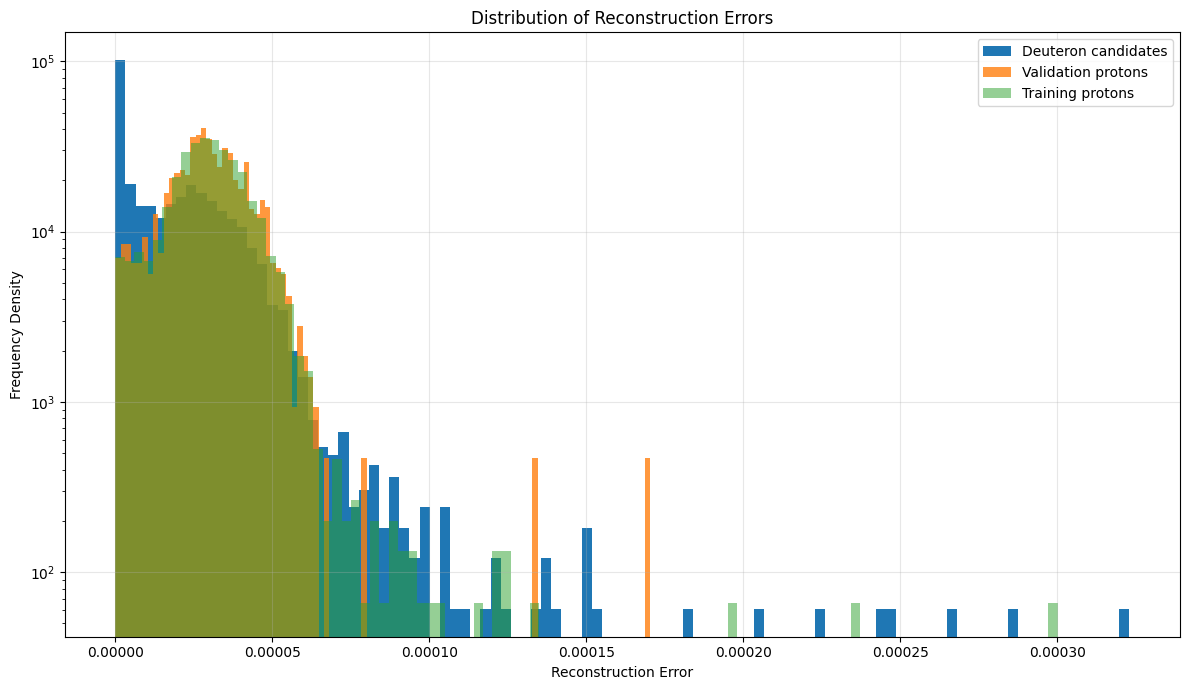

In [ ]:
plt.figure(figsize=(12, 7))

plt.hist(RE_per_sample_d, bins=100, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=100, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=100, alpha=0.5, label='Training protons', density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency Density")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.legend()
plt.tight_layout()
plt.show()

Found 4901 samples


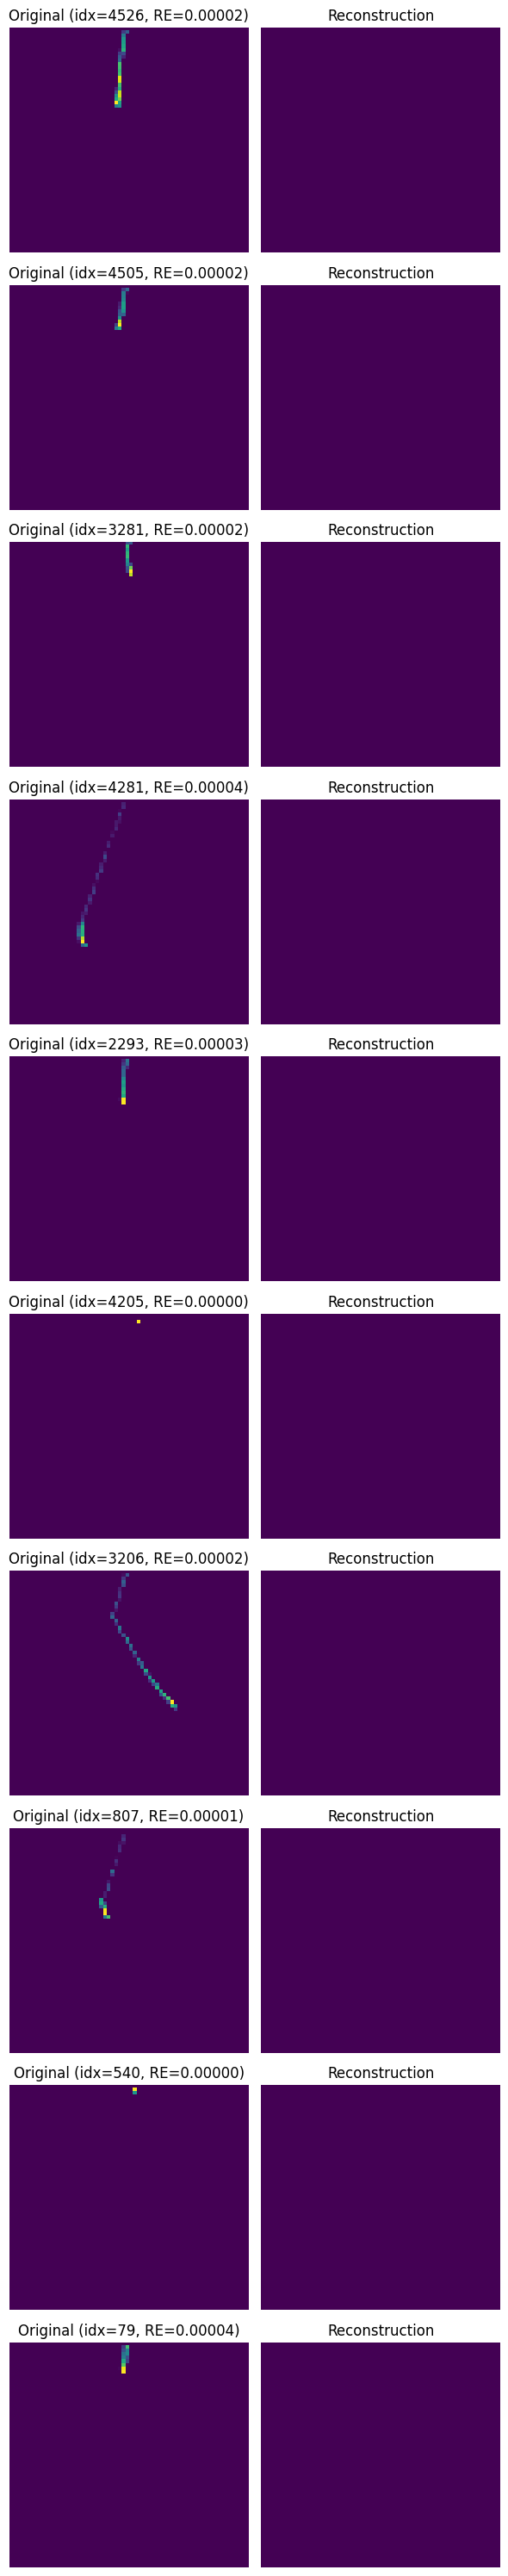

In [ ]:
high_re_idx = np.where((RE_per_sample_d > 0) & (RE_per_sample_d < 20))[0]
print(f"Found {len(high_re_idx)} samples")

k = min(10, len(high_re_idx))
if k == 0:
    print("No samples with RE > 200 found.")
else:
    selected = np.random.choice(high_re_idx, size=k, replace=False)

    fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
    for ii in range(k):
        idx = selected[ii]
        axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.5f})")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Reconstruction")
        axs[ii, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
x = deuterons['beamline_mass'].values

deuterons.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes', 'normalised',
       'adcdiff', 'maxdiff', 'energy', 'rr', 'e_diff', 'rr_diff', 'p', 'm',
       'beamline_mass'],
      dtype='object')

Text(0.5, 0, 'Mass')

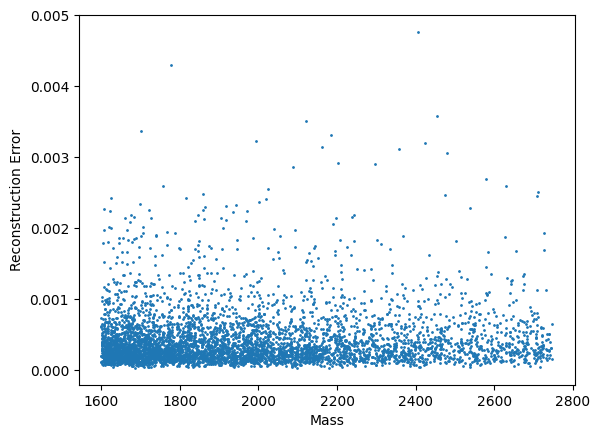

In [ ]:
plt.scatter(x, RE_per_sample_d, s=1)
# plt.ylim(-5, 100)
plt.ylabel('Reconstruction Error')
plt.xlabel('Mass')

In [ ]:
latent_vectors_d.shape, RE_per_sample_d.shape, recon_all_d.shape

((5115, 16), (5115,), (5115, 64, 64))

In [ ]:
latent_vectors.shape, RE_per_sample.shape, recon_all.shape

((5033, 16), (5033,), (5033, 64, 64))

In [ ]:
latent_vectors_val.shape, RE_per_sample_val.shape, recon_all_val.shape

((1258, 16), (1258,), (1258, 64, 64))

In [ ]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

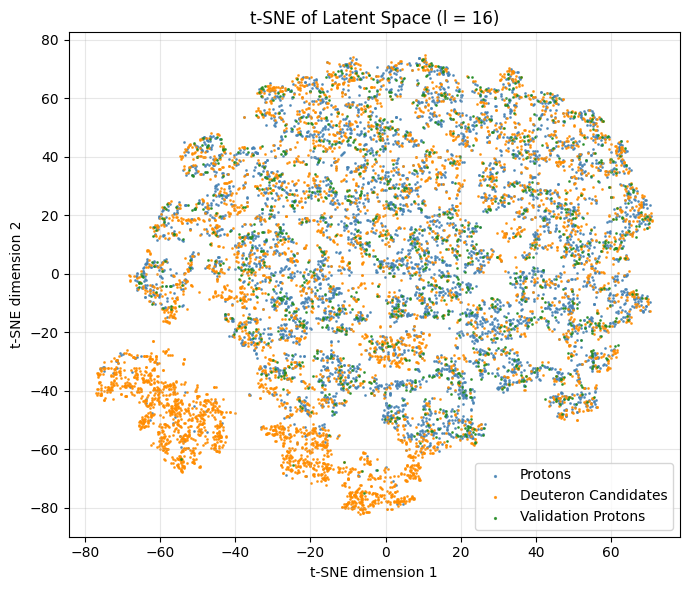

In [ ]:
%matplotlib inline

# Plot with three colours
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Deuteron Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

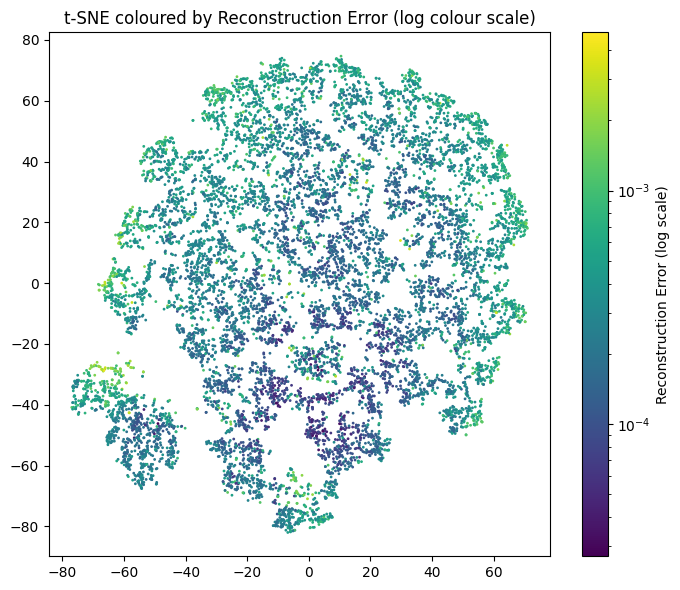

In [ ]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_d, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# low error regions and high error regions in deuteron candidates?
# overlap with proton latent vectors?
# separation with proton latent vectors

In [ ]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


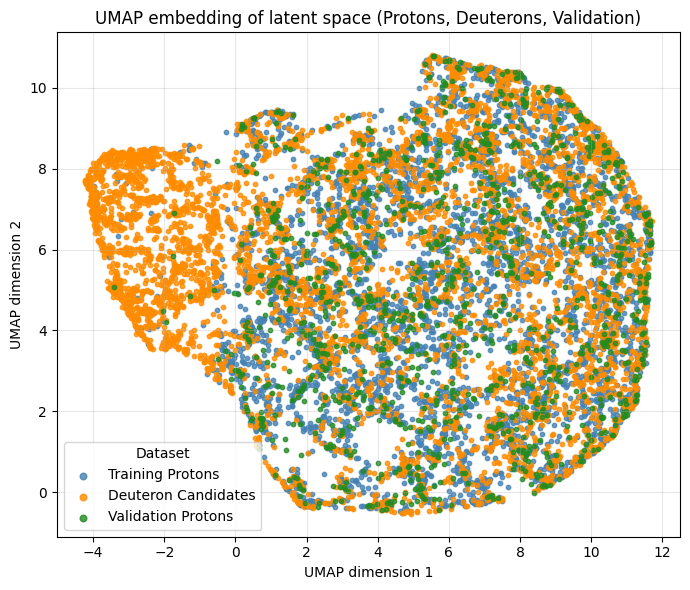

In [ ]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


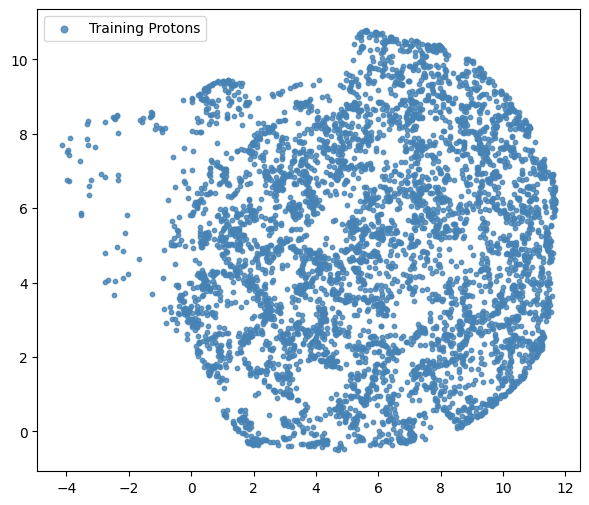

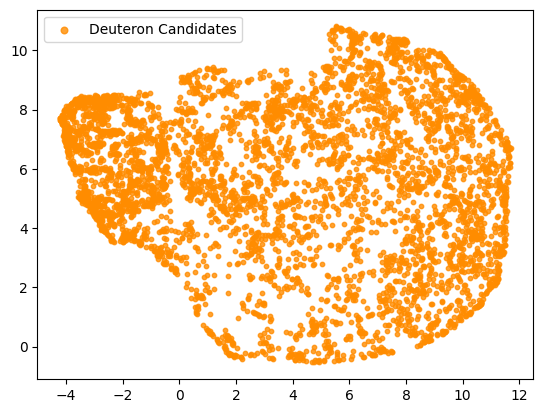

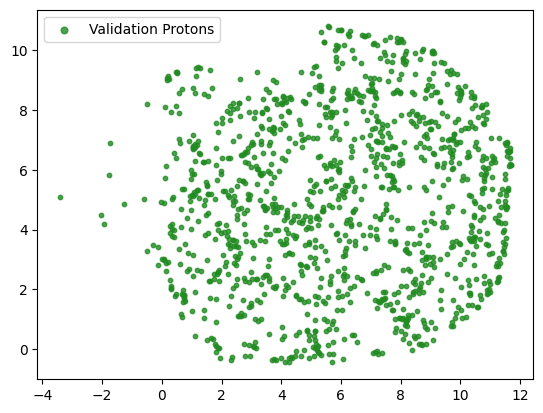

In [ ]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    # plt.xlim(-5, 14)
    # plt.ylim(0, 10)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


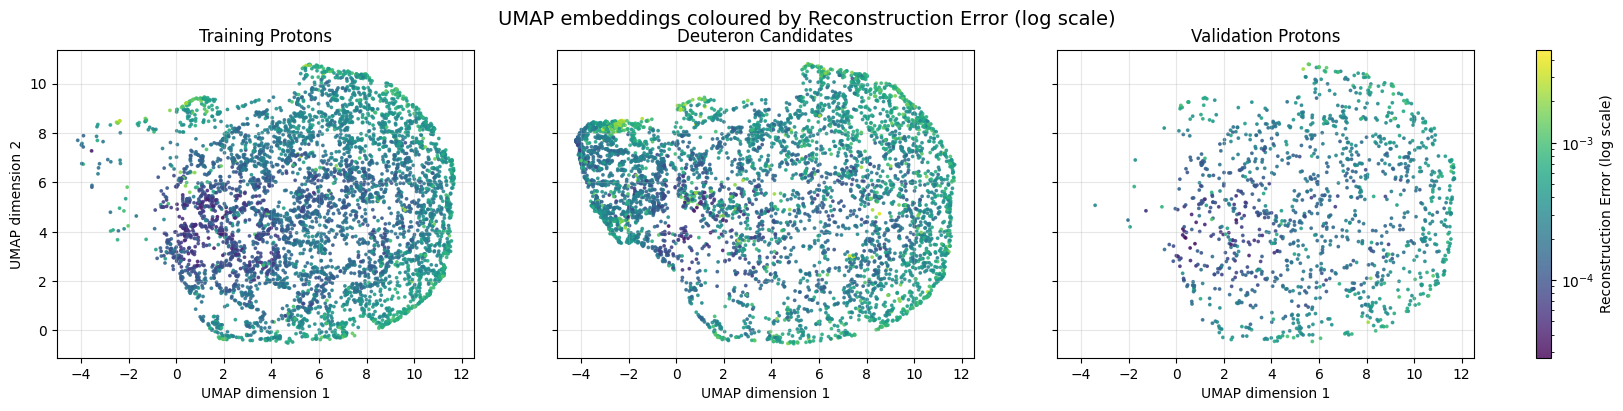

In [ ]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)

plt.savefig('UMAPandRE.png', dpi=1000)
plt.show()


In [ ]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D

umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    mask = (labels == i)
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=2,
        alpha=0.8,
        label=name
    )

ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding of latent space (Protons, Deuterons, Validation)")
ax.legend(title="Dataset", loc="upper right")

# ax.view_init(elev=45, azim=45)         # azim 0 along x, 90 along y

plt.tight_layout()
plt.show()

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 640x480 with 0 Axes>

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


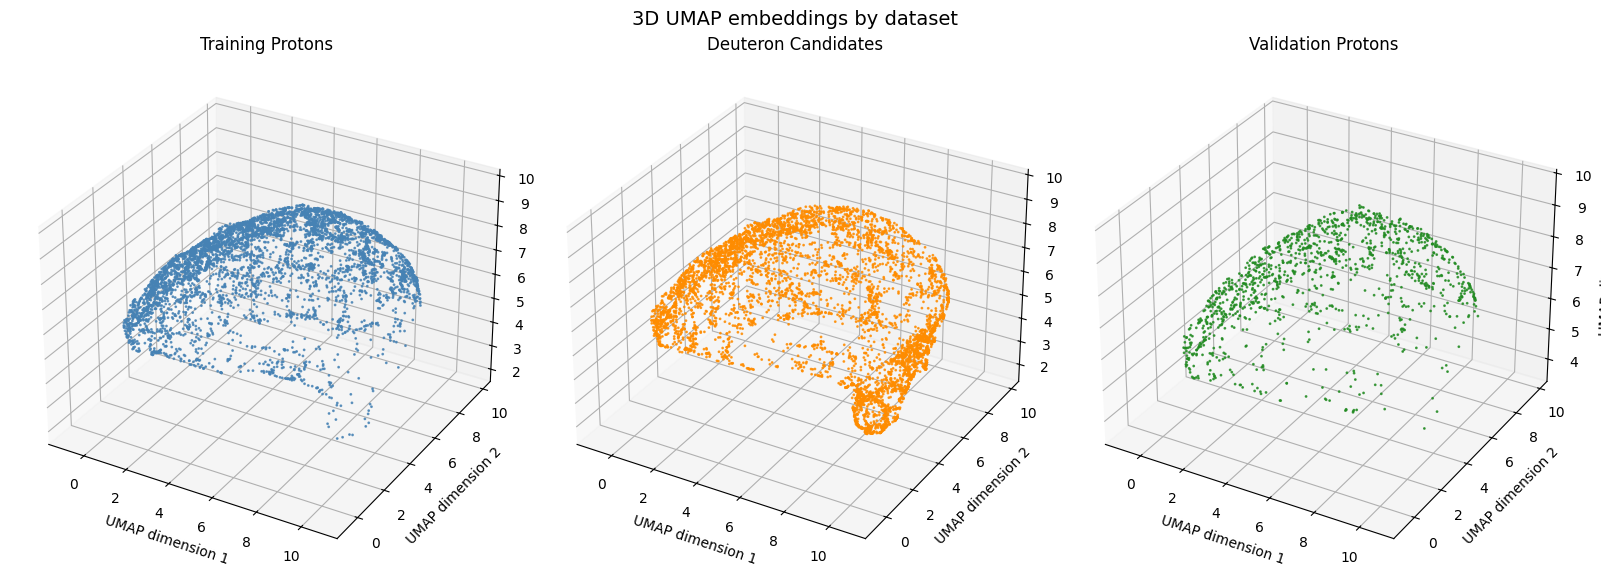

In [ ]:
umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(16, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8
    )
    ax.set_title(name)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  

fig.suptitle("3D UMAP embeddings by dataset", fontsize=14)
plt.tight_layout()
plt.show()


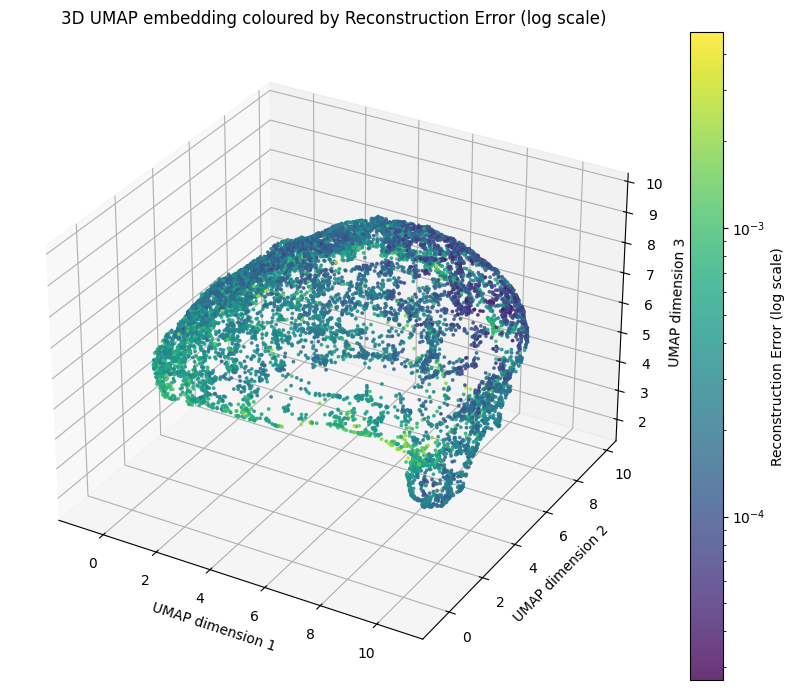

In [ ]:
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot coloured by reconstruction error
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=RE_all,
    cmap='viridis',
    norm=mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max()),
    s=3,
    alpha=0.8
)

# Axis labels and title
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding coloured by Reconstruction Error (log scale)")

# Colour bar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

plt.tight_layout()
plt.show()


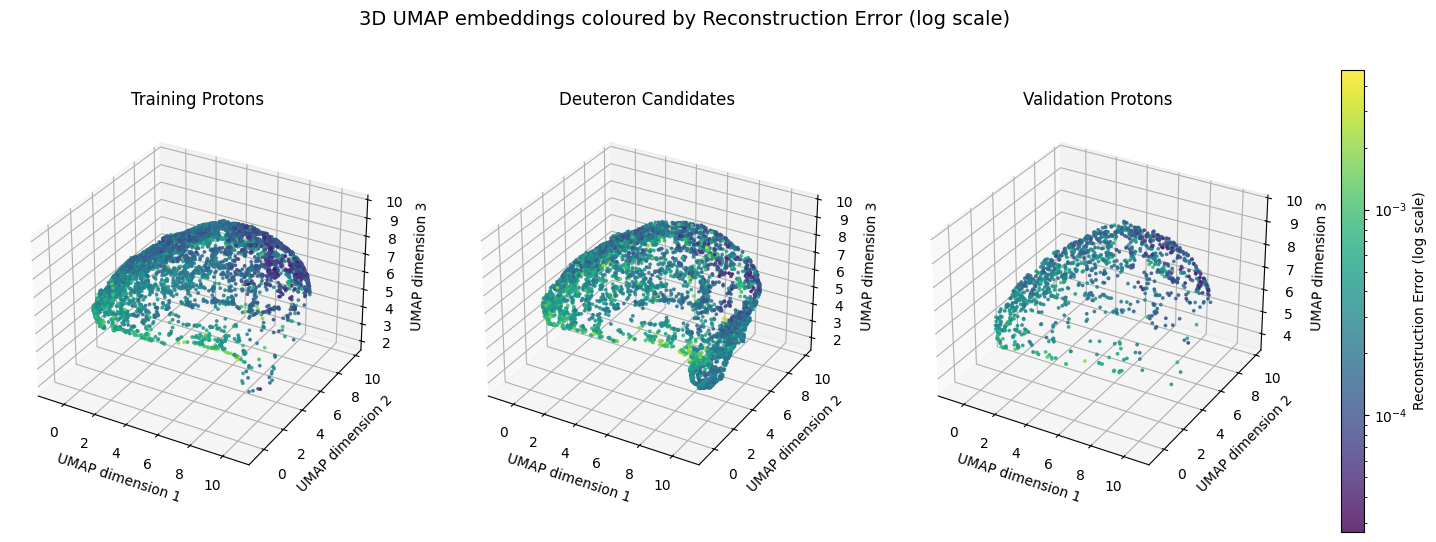

In [ ]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assume: embedding (3D UMAP), RE_all (reconstruction errors), labels (0,1,2)
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# Shared normalisation and colormap for all plots
norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    sc = ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        c=RE_all[mask],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  # consistent 3D orientation

# Shared colour bar for all subplots
cbar = fig.colorbar(sc, ax=fig.get_axes(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("3D UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


In [ ]:
latent_vectors.shape, latent_vectors_val.shape, latent_vectors_d.shape

((5033, 16), (1258, 16), (5115, 16))

In [ ]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

Deuteron subset shape: (5115, 2)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

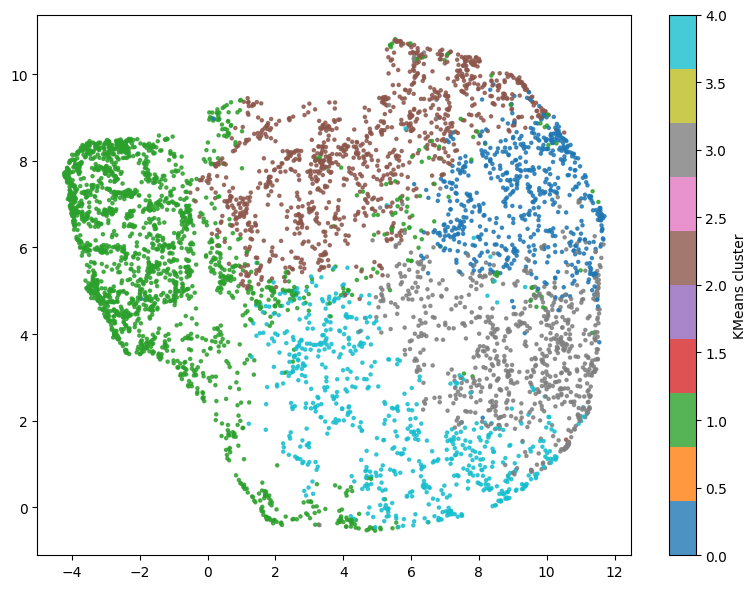

In [ ]:
from sklearn.cluster import KMeans

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(Z_d)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


In [ ]:
unique, counts = np.unique(highlight_mask, return_counts=True)

unique, counts

(array([False,  True]), array([4899,  216]))

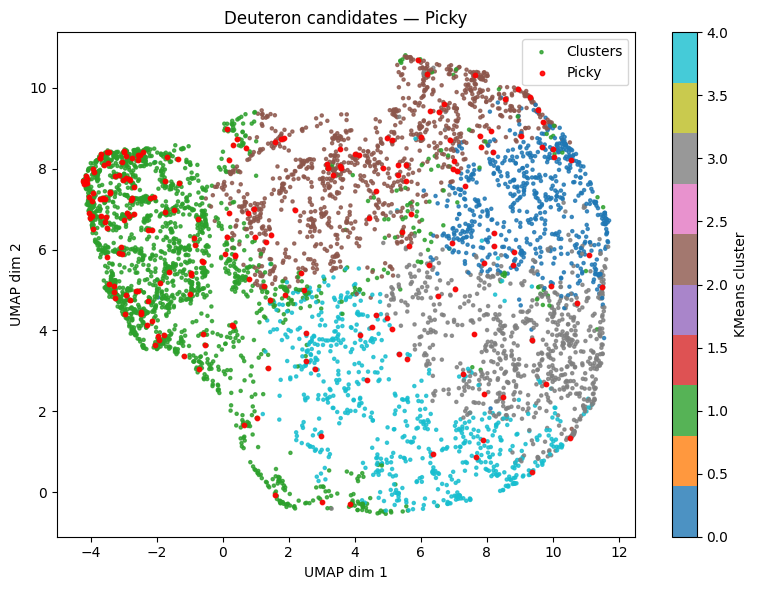

In [ ]:
# Highlight points where highlight == 1
highlight_mask = (d_p == 1)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], c=labels_km, cmap='tab10', s=5, alpha=0.8, label='Clusters')

# Overlay highlighted points
plt.scatter(E_d[highlight_mask, 0], E_d[highlight_mask, 1], 
            color='red', s=10, label='Picky', alpha=0.9)

plt.colorbar(sc, label='KMeans cluster')
plt.title("Deuteron candidates — Picky")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.legend()
plt.tight_layout()
plt.show()

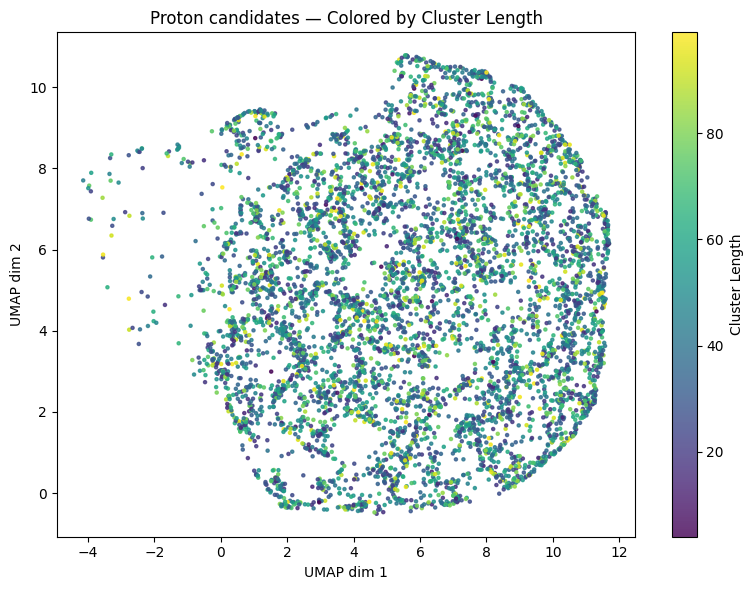

In [ ]:
fig = plt.figure(figsize=(8, 6))

mask = ((labels == 0) | (labels == 2))
Z_p = Z_all[mask]          # latent vectors
E_p = Z_umap[mask]      # 3D UMAP coordinates

p_l = protons['height'].values

# Scatter plot colored by cluster length
sc = plt.scatter(E_p[:, 0], E_p[:, 1],
                 c=p_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Proton candidates — Colored by Cluster Length")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

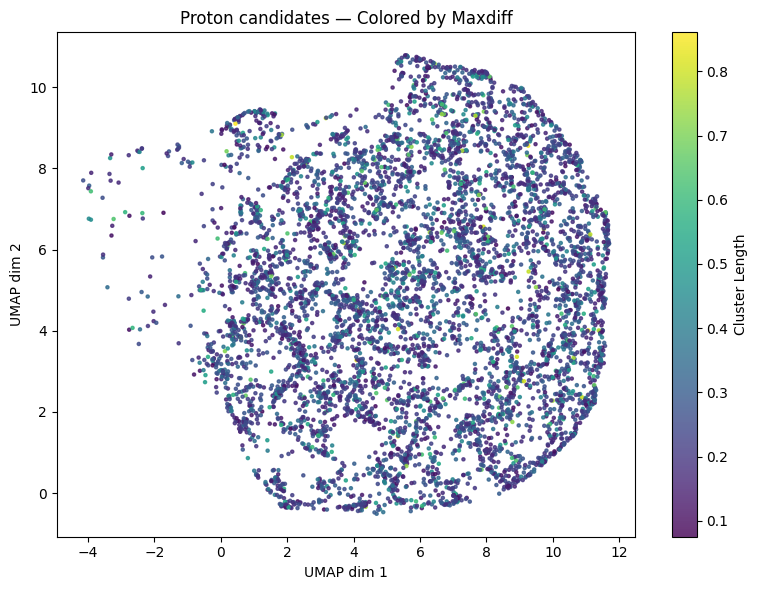

In [ ]:
fig = plt.figure(figsize=(8, 6))

mask = ((labels == 0) | (labels == 2))
Z_p = Z_all[mask]          # latent vectors
E_p = Z_umap[mask]      # 3D UMAP coordinates

p_l = protons['maxdiff'].values

# Scatter plot colored by cluster length
sc = plt.scatter(E_p[:, 0], E_p[:, 1],
                 c=p_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Proton candidates — Colored by Maxdiff")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

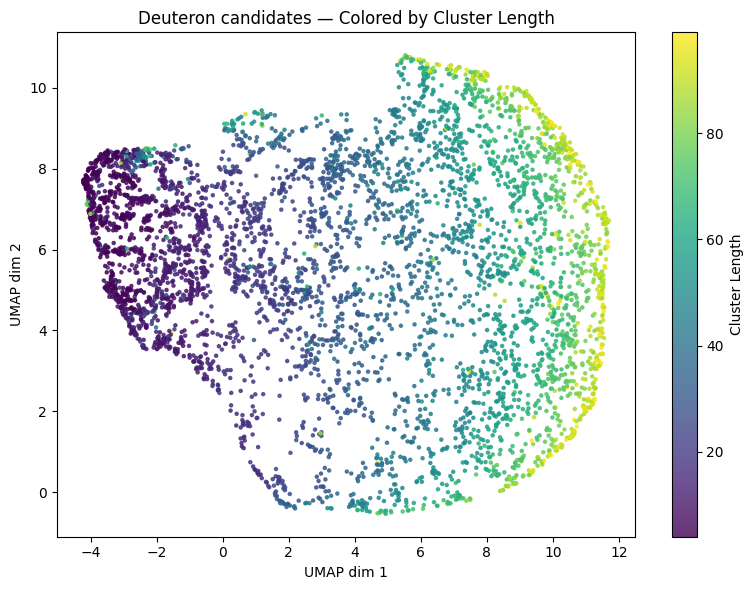

In [ ]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Deuteron candidates — Colored by Cluster Length")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

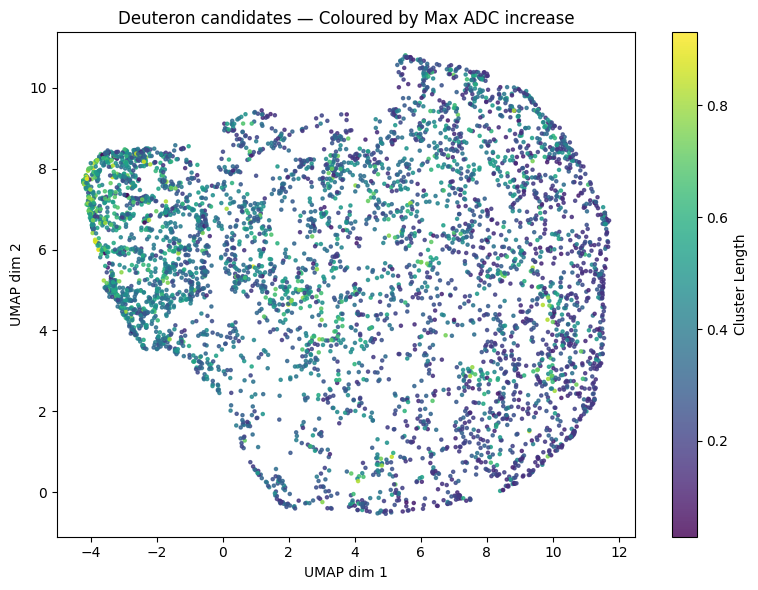

In [ ]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_diff, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Deuteron candidates — Coloured by Max ADC increase")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

In [ ]:
p_m = protons['beamline_mass'].values
d_m = deuterons['beamline_mass'].values

d_l = deuterons['height'].values
d_p = deuterons['p'].values
d_diff = deuterons['maxdiff'].values

labels = labels_km

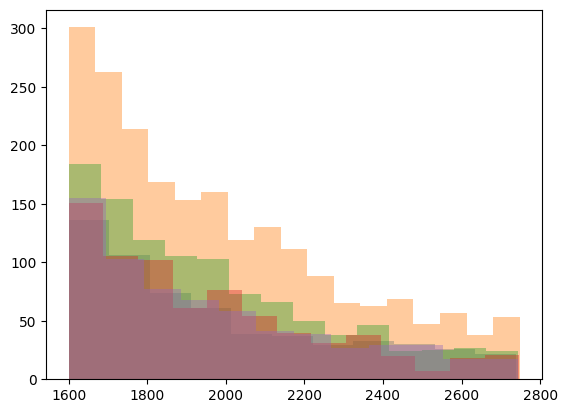

In [ ]:
for i in range(5):
    mass = d_m[labels == i]
    plt.hist(mass, bins='auto', alpha=0.4, label=f'Label {i}')

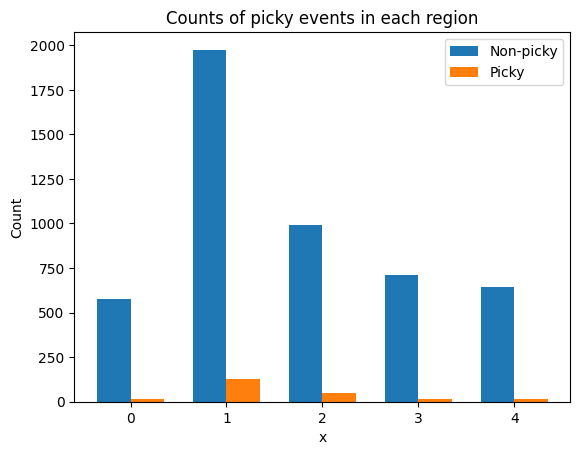

In [ ]:
k = 5
counts = np.zeros((k, 2))  # rows: x, cols: label
for i in range(k):
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

x_vals = np.arange(k)  # positions for x = 0, 1
width = 0.35

plt.bar(x_vals - width/2, counts[:, 0], width, label='Non-picky', color='tab:blue')
plt.bar(x_vals + width/2, counts[:, 1], width, label='Picky', color='tab:orange')

# plt.xticks(x_vals, ['x=0', 'x=1', 'x=2', 'x=3'])
plt.ylabel('Count')
plt.xlabel('x')
plt.legend()
plt.title('Counts of picky events in each region')
plt.show()


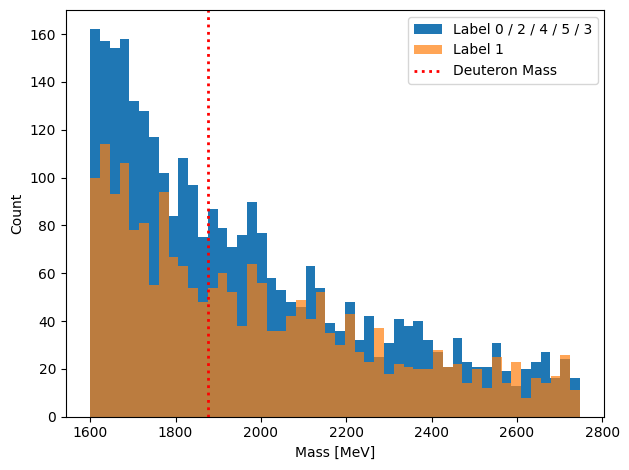

In [ ]:
mass_0 = d_m[(labels == 0) | (labels == 2) | (labels == 4) | (labels == 5) | (labels == 3)]
mass_1 = d_m[(labels == 1)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0 / 2 / 4 / 5 / 3', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

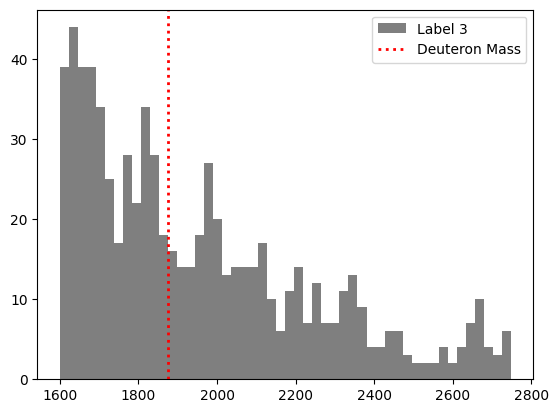

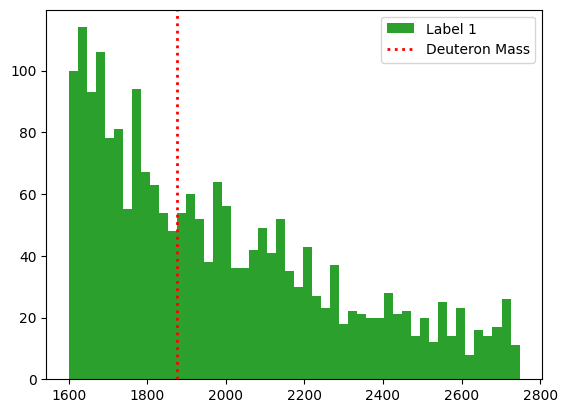

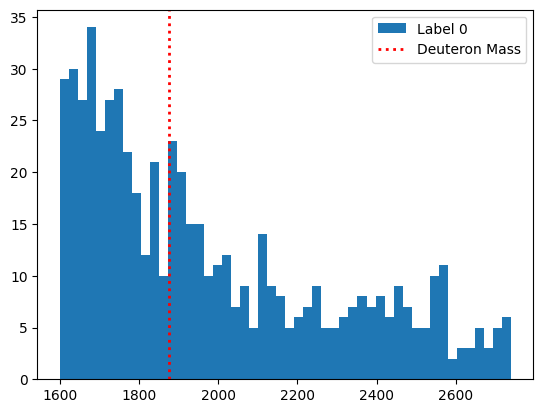

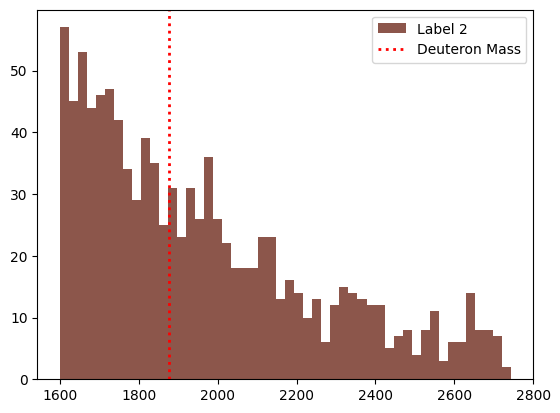

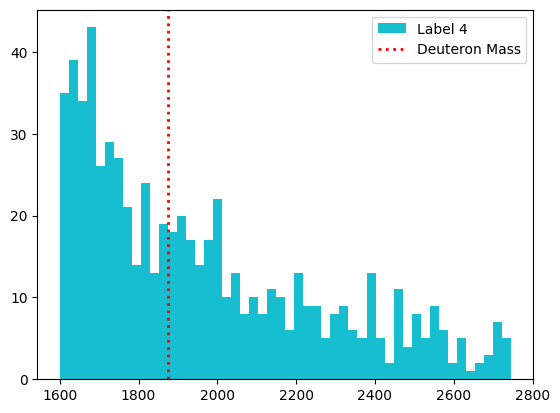

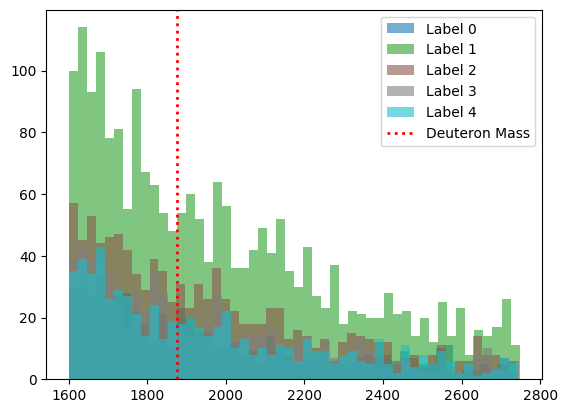

In [ ]:
labels = labels_km

m0 = d_m[(labels == 0)]
m1 = d_m[(labels == 1)]
m2 = d_m[(labels == 2)]
m3 = d_m[(labels == 3)]
m4 = d_m[(labels == 4)]


label_colours = {
    0: 'tab:blue',   
    1: 'tab:green',  
    2: 'tab:brown',  
    3: 'tab:gray',   
    4: 'tab:cyan'   
}

plt.hist(m3, bins=50, alpha=1, color=label_colours[3], label='Label 3')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m1, bins=50, alpha=1, color=label_colours[1], label='Label 1')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m0, bins=50, alpha=1, color=label_colours[0], label='Label 0')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m2, bins=50, alpha=1, color=label_colours[2], label='Label 2')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m4, bins=50, alpha=1, color=label_colours[4], label='Label 4')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

for i, m in enumerate([m0, m1, m2, m3, m4]):
    plt.hist(m, bins=50, alpha=0.6, color=label_colours[i], label=f'Label {i}')

plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()


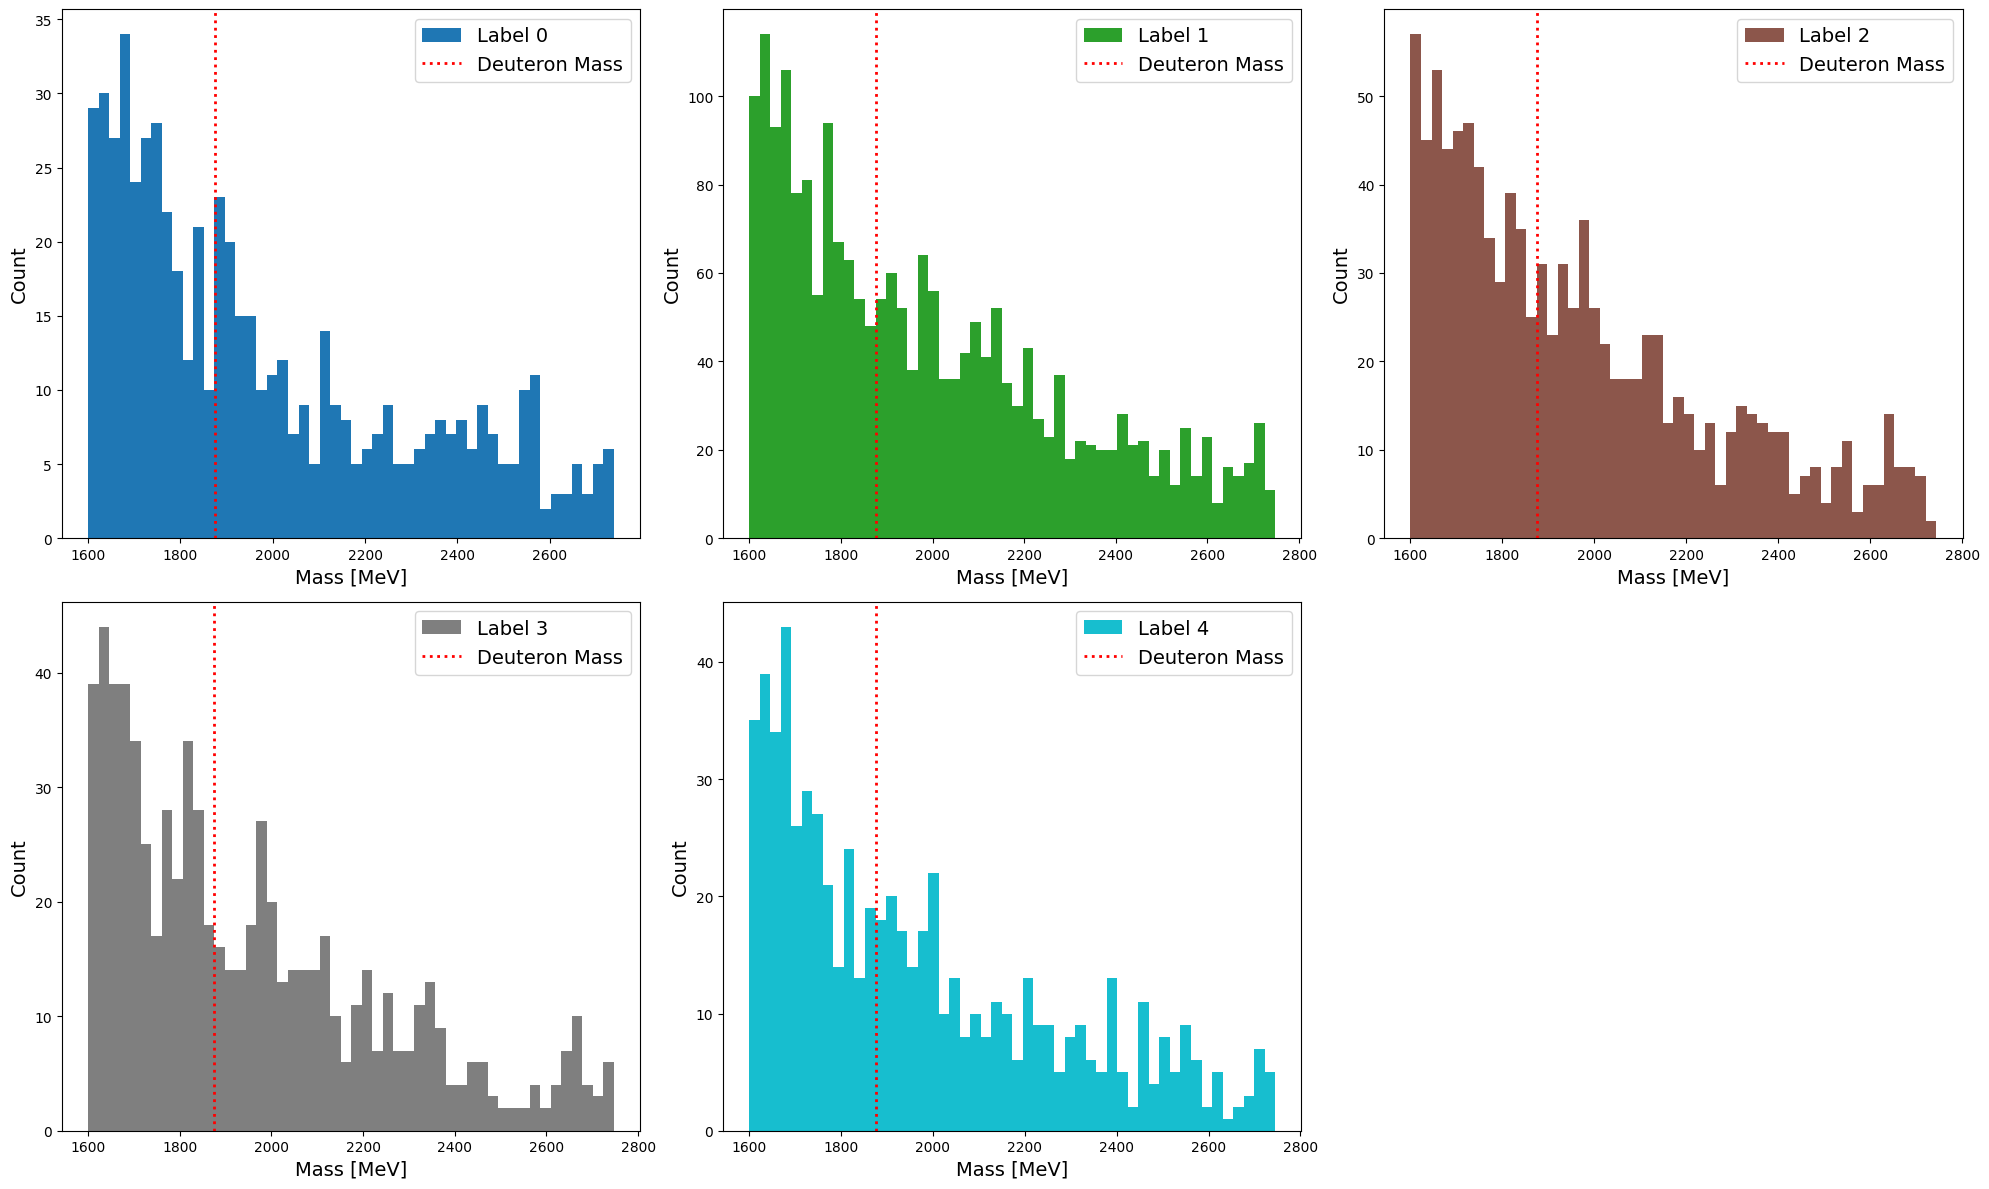

In [ ]:
import matplotlib.pyplot as plt

# Define consistent colours
label_colours = {
    0: 'tab:blue',
    1: 'tab:green',
    2: 'tab:brown',
    3: 'tab:gray',
    4: 'tab:cyan'
}

# Your datasets
datasets = {0: m0, 1: m1, 2: m2, 3: m3, 4: m4}

# Create a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, label in enumerate(datasets.keys()):
    ax = axes[i]
    ax.hist(datasets[label], bins=50, alpha=1, color=label_colours[label], label=f'Label {label}')
    ax.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
    ax.legend(fontsize=14)
    ax.set_xlabel('Mass [MeV]', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

# Hide any unused subplot (since we have 5 plots but 6 slots)
for j in range(len(datasets), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('labelsvmass.png', dpi=500)
plt.show()


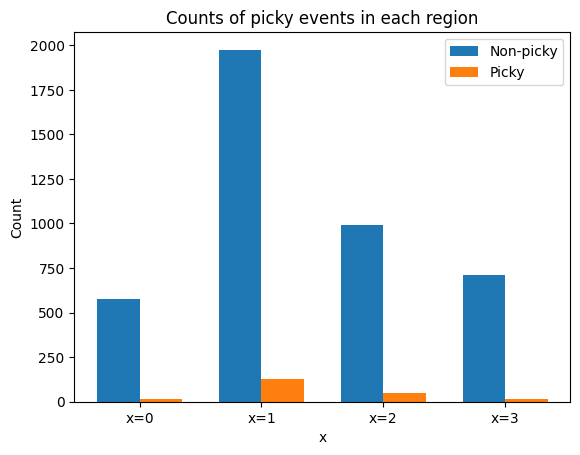

In [ ]:
counts = np.zeros((4, 2))  # rows: x, cols: label
for i in [0, 1, 2, 3]:
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

x_vals = np.arange(4)  # positions for x = 0, 1
width = 0.35

plt.bar(x_vals - width/2, counts[:, 0], width, label='Non-picky', color='tab:blue')
plt.bar(x_vals + width/2, counts[:, 1], width, label='Picky', color='tab:orange')

plt.xticks(x_vals, ['x=0', 'x=1', 'x=2', 'x=3'])
plt.ylabel('Count')
plt.xlabel('x')
plt.legend()
plt.title('Counts of picky events in each region')
plt.show()


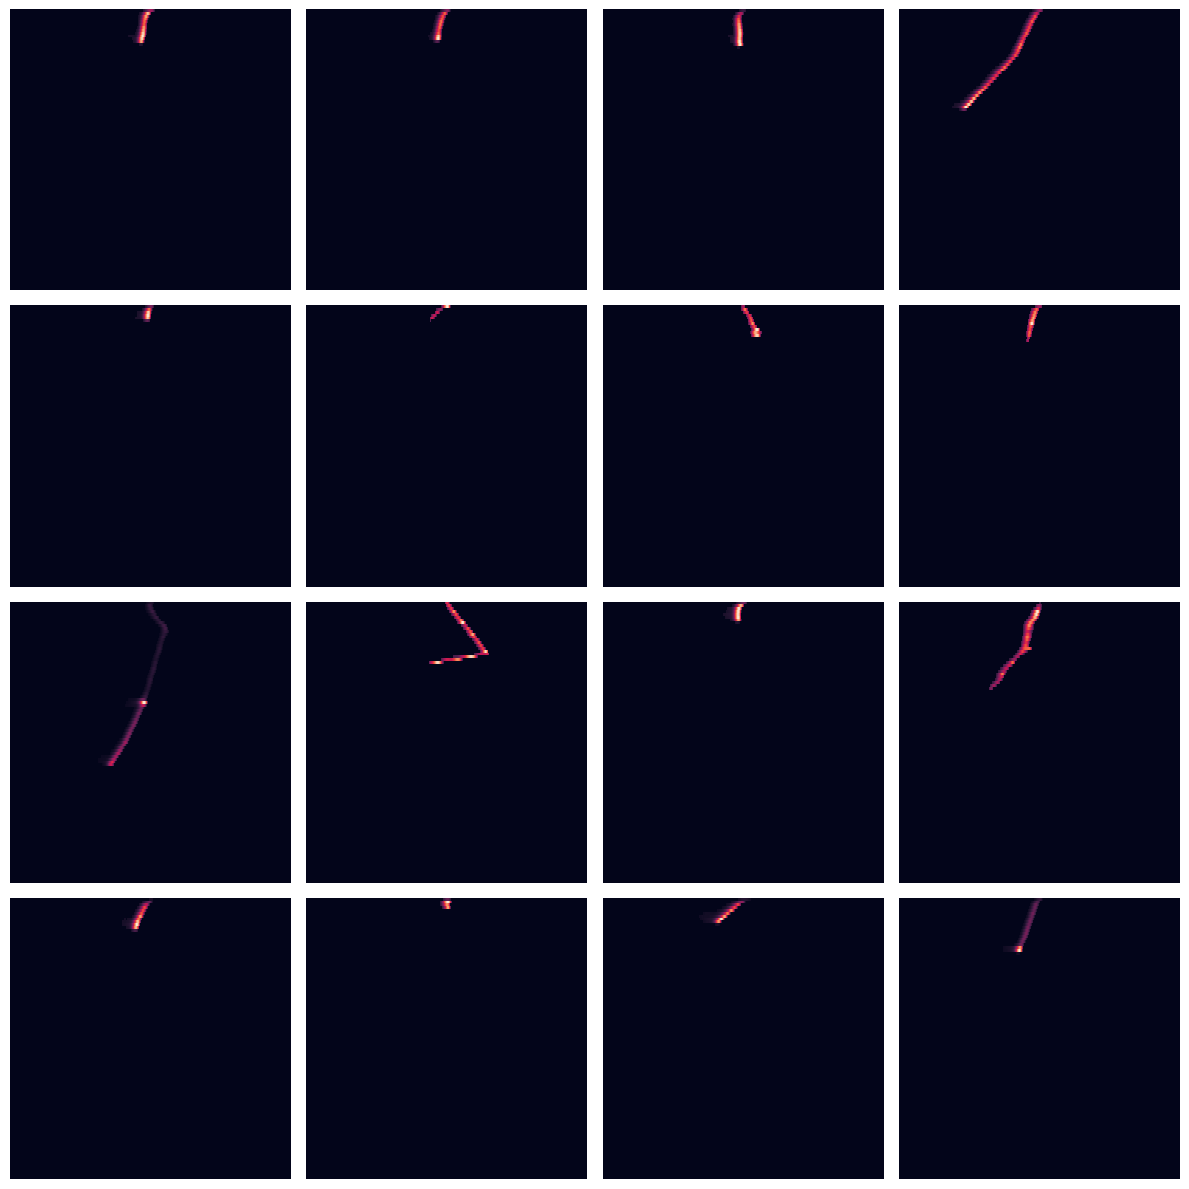

In [ ]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

# Filter the original images for the selected cluster
cluster_id = 1 # Change this to the desired cluster ID
cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]

# Select up to `num_images` images from the cluster
selected_images = d[cluster_indices[:num_images]]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

plt.tight_layout()
plt.show()

In [ ]:
cluster_id = 0

cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]
print(f"Cluster {cluster_id}: {len(cluster_indices)} samples")

# filtered_idx = cluster_indices[(RE_per_sample_d[cluster_indices] >= 0) &
#                                (RE_per_sample_d[cluster_indices] < 3000)]

# print(f"Filtered: {len(filtered_idx)} samples with RE in range")

# k = min(10, len(filtered_idx))
# if k == 0:
#     print(f"No samples found in cluster {cluster_id} with RE in range.")
# else:
#     selected = np.random.choice(filtered_idx, size=k, replace=False)

#     fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
#     for ii in range(k):
#         idx = selected[ii]
#         axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
#         axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
#         axs[ii, 0].axis('off')

#         axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
#         axs[ii, 1].set_title("Reconstruction")
#         axs[ii, 1].axis('off')

#     plt.tight_layout()
#     plt.show()



Cluster 0: 706 samples


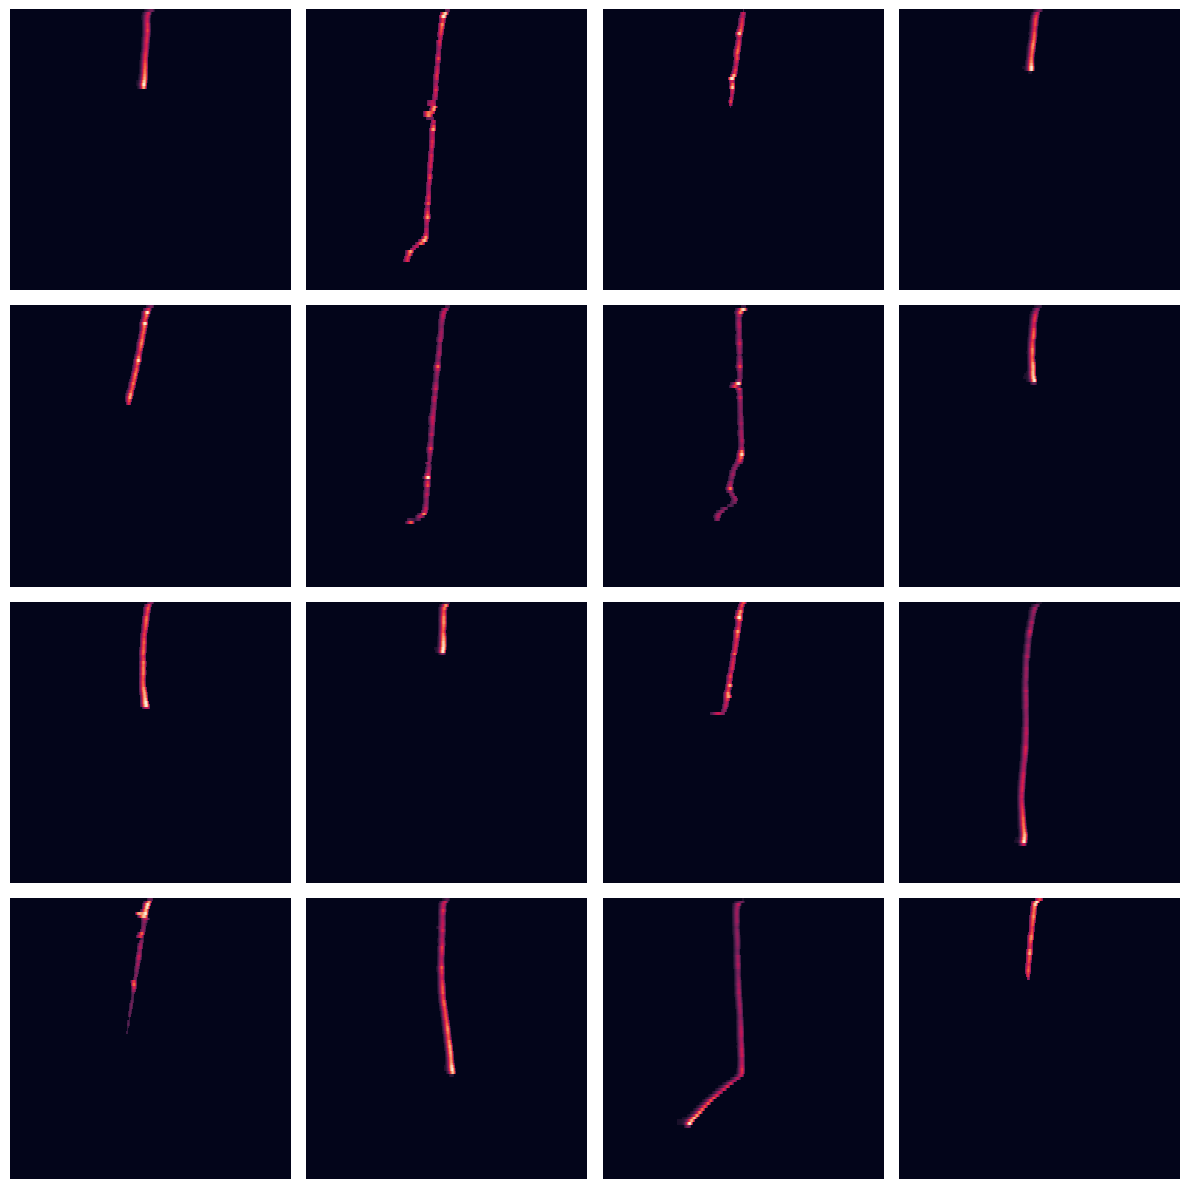

In [ ]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

# Filter the original images for the selected cluster
cluster_id = 2  # Change this to the desired cluster ID
cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]

# Randomly select up to `num_images` images from the cluster
if len(cluster_indices) > num_images:
    selected_indices = np.random.choice(cluster_indices, size=num_images, replace=False)
else:
    selected_indices = cluster_indices

selected_images = d[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

plt.tight_layout()
plt.show()

Cluster 3: 2176 samples
Filtered: 2176 samples with RE in range


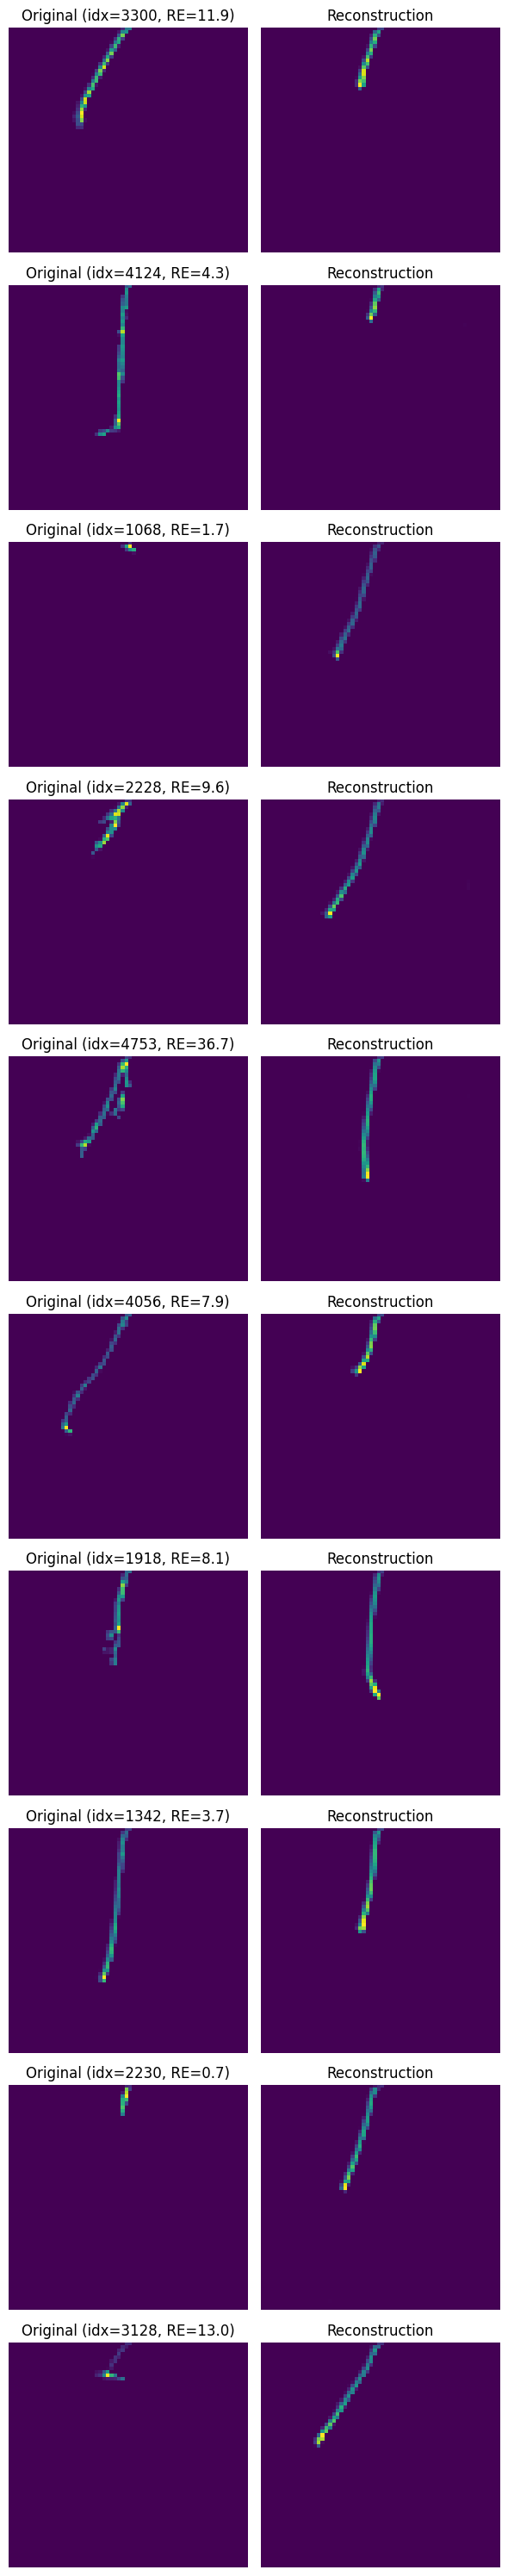

In [ ]:
cluster_id = 3

cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]
print(f"Cluster {cluster_id}: {len(cluster_indices)} samples")

filtered_idx = cluster_indices[(RE_per_sample_d[cluster_indices] >= 0) &
                               (RE_per_sample_d[cluster_indices] < 3000)]

print(f"Filtered: {len(filtered_idx)} samples with RE in range")

k = min(10, len(filtered_idx))
if k == 0:
    print(f"No samples found in cluster {cluster_id} with RE in range.")
else:
    selected = np.random.choice(filtered_idx, size=k, replace=False)

    fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
    for ii in range(k):
        idx = selected[ii]
        axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Reconstruction")
        axs[ii, 1].axis('off')

    plt.tight_layout()
    plt.show()

Deuteron subset shape: (5115, 2)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_40836/859799654.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)


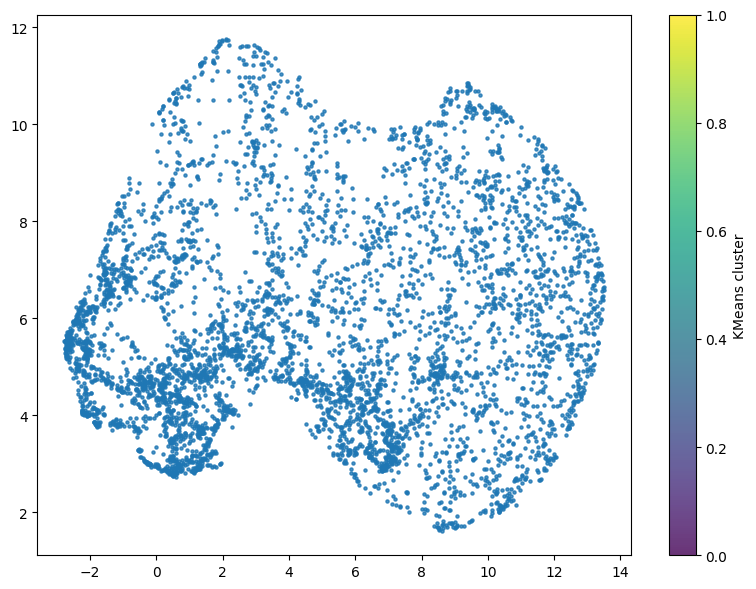

In [ ]:
Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")


fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


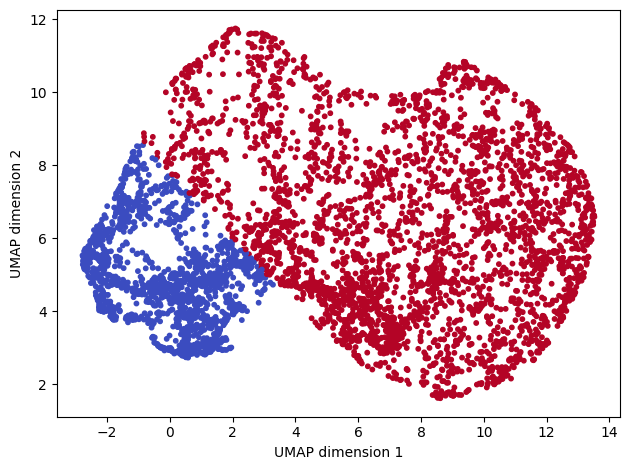

In [ ]:

# Example: UMAP coordinates
x = E_d[:, 0]
y = E_d[:, 1]

# Define your line: y = m*x + c
m = -0.9    # slope
c = 7.8    # intercept

# Compute which side each point is on
side = y > (m * x + c)
labels = side.astype(int)   # 0 or 1 cluster assignment

# Plot
# plt.figure(figsize=(7, 5))
plt.scatter(x, y, c=labels, cmap='coolwarm', s=10)
# plt.plot(x, m*x + c, 'k--', linewidth=2, label='Manual boundary')
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
# plt.legend()
plt.tight_layout()
plt.show()


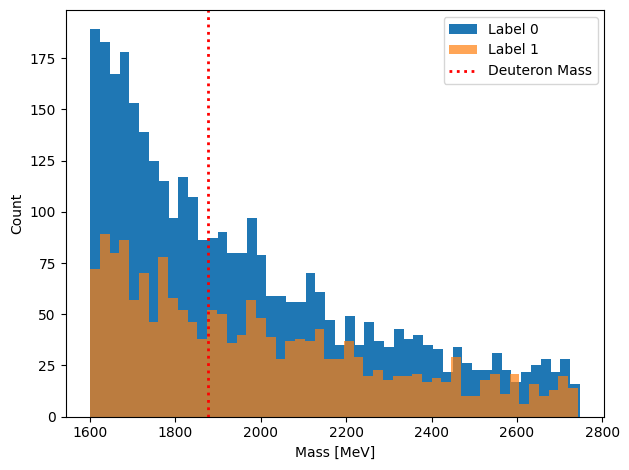

In [ ]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

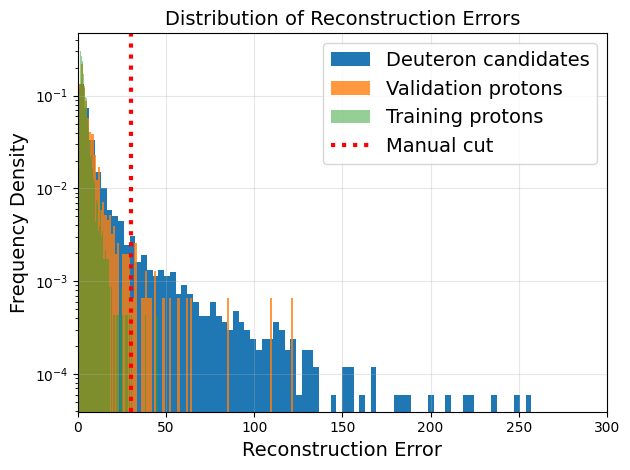

In [ ]:
# plt.figure(figsize=(12, 7))

plt.hist(RE_per_sample_d, bins=100, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=100, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=100, alpha=0.5, label='Training protons', density=True)

plt.axvline(30, linewidth=3, linestyle=":", c='red', label='Manual cut')

plt.xlabel("Reconstruction Error", fontsize=14)
plt.ylabel("Frequency Density", fontsize=14)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('reconerror.png', dpi=1000)
plt.show()

In [ ]:
unique, counts = np.unique(labels, return_counts=True)
unique, counts

(array([False,  True]), array([4743,  372]))

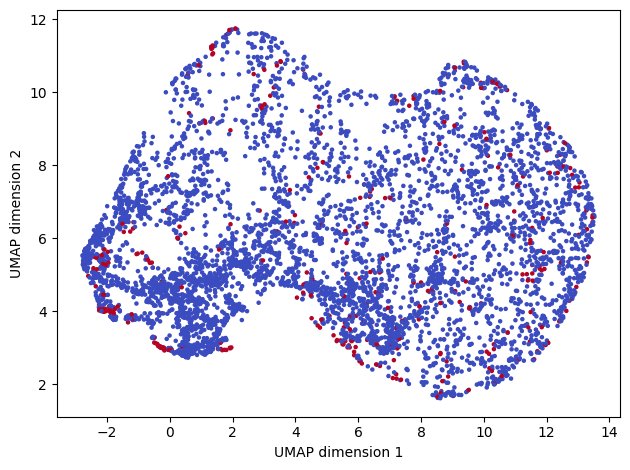

In [ ]:
labels = RE_per_sample_d > 30

x = E_d[:, 0]
y = E_d[:, 1]

plt.scatter(x, y, c=labels, cmap='coolwarm', s=5)
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.show()


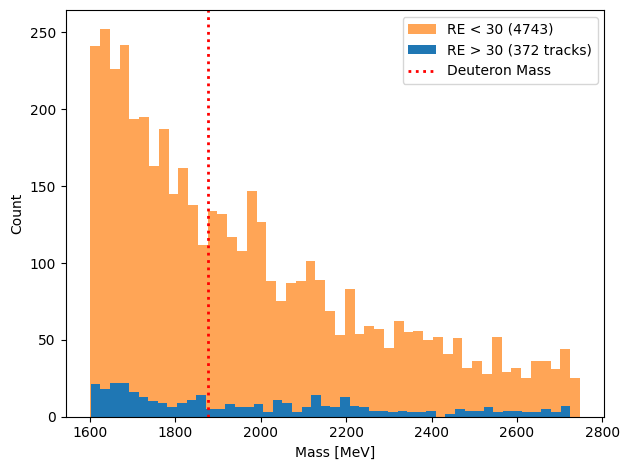

In [ ]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot

plt.hist(mass_1, bins=50, alpha=0.7, label='RE < 30 (4743)', color='tab:orange')
plt.hist(mass_0, bins=50, alpha=1.0, label='RE > 30 (372 tracks)', color='tab:blue')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()